# Анализ лояльности пользователей Яндекс Афиши

**0.1 Цели и задачи проекта**

**Цель:** провести исследование лояльности пользователей Яндекс Афиши

**Задачи проекта:**
1.  Выгрузить данные из БД SQL в датафрейм pandas, чтобы выполнять дальнейшую работу с помощью Python и библиотек анализа данных.
2.	Выполнить предобработку данных.
3.	Сформирроватье профиль пользователя, выделив признаки и факторы, которые могут влиять на повторные заказы.
4.	Выяснить, как распределены данные и какие закономерности в них наблюдаются.
5.	Провести корреляционный анализ и вычислите коэффициенты phik, чтобы узнать, какие признаки влияют на количество заказов.


## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных 


Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


Начнём с загрузки библиотек. Будем использовать **pandas** и библиотеки визуализации данных **matplotlib** и **seaborn**, а также **phik** для построения матрицы корреляции.

Установим библиотеку phik командой:

In [1]:
!pip install phik

In [12]:
from dotenv import load_dotenv
import os

import pandas as pd
from sqlalchemy import create_engine 

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
from phik import phik_matrix

Для подключения к базе данных Практикума создадим объект df_config и сохраним в неём основные параметры подключения

In [19]:
# Загружаем переменные из .env-файла
load_dotenv('C:\\Kat\\DataMining\\work_terminal\\project_Afisha\\.env')

# Формируем словарь с настройками БД
db_config = {
    'user': os.getenv('USER'),                    # имя пользователя
    'pwd': os.getenv('PWD'),                     # пароль
    'host': os.getenv('HOST'),                   # хост
    'port': int(os.getenv('PORT')),              # порт (преобразуем в число)
    'db': os.getenv('DB')                       # название базы данных
}

print(db_config)  # Проверка — выведет готовый словарь




{'user': 'praktikum_student', 'pwd': 'Sdf4$2;d-d30pp', 'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net', 'port': 6432, 'db': 'data-analyst-afisha'}


Содаём строку для подключения с помощью метода  `format()`:

In [20]:
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
) 

Чтобы создать соединение, строку с данными для подключения передаём функции create_engine():

In [21]:
engine = create_engine(connection_string) 

Создаём запрос query и сохраним ёго данные в датафрейме df

In [22]:
query = '''
SELECT p.order_id,
       p.user_id,
       p.created_dt_msk AS order_dt,
       p.created_ts_msk AS order_ts,
       p.event_id,
       p.currency_code,
       p.device_type_canonical,
       p.revenue,
       p.tickets_count,
       ROUND(p.created_dt_msk::date-LAG(p.created_dt_msk::date) OVER(PARTITION BY p.user_id ORDER BY p.created_dt_msk)) AS days_since_prev,
       e.event_name_code AS event_name,--
       e.event_type_main,--
       p.service_name,-- 
       r.region_name,--
       c.city_name--  
FROM afisha.purchases p 
     INNER JOIN afisha.events e ON p.event_id =e.event_id 
     INNER JOIN afisha.city c ON e.city_id =c.city_id
     INNER JOIN afisha.regions r ON c.region_id =r.region_id
WHERE p.device_type_canonical IN('desktop','mobile') AND e.event_type_main != 'фильм'
ORDER BY user_id;

''' 

In [23]:
df = pd.read_sql_query(query, con=engine) 

In [25]:
df.head()

,order_id,user_id,order_dt,order_ts,event_id,currency_code,device_type_canonical,revenue,tickets_count,days_since_prev,event_name,event_type_main,service_name,region_name,city_name
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,rub,mobile,1521.94,4,NaN,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,rub,mobile,289.45,2,NaN,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,rub,mobile,1258.57,4,75.0,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,rub,mobile,8.49,2,NaN,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,rub,mobile,1390.41,3,83.0,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк


---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   order_id               290611 non-null  int64         
 1   user_id                290611 non-null  object        
 2   order_dt               290611 non-null  datetime64[ns]
 3   order_ts               290611 non-null  datetime64[ns]
 4   event_id               290611 non-null  int64         
 5   currency_code          290611 non-null  object        
 6   device_type_canonical  290611 non-null  object        
 7   revenue                290611 non-null  float64       
 8   tickets_count          290611 non-null  int64         
 9   days_since_prev        268678 non-null  float64       
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

In [10]:
# Выведем на экран названия всех столбцов датафрейма
print(df.columns)

Index(['order_id', 'user_id', 'order_dt', 'order_ts', 'event_id',
       'currency_code', 'device_type_canonical', 'revenue', 'tickets_count',
       'days_since_prev', 'event_name', 'event_type_main', 'service_name',
       'region_name', 'city_name'],
      dtype='object')


Названия столбцов соответствуют стилю **snake case**. Ничего не меняем

строк **209611**, столбцов **15**. Пропуски в 1 столбце `days_since_prev`.

- `order_id`, `event_id`, `tickets_count` - тип **int64** правильный, оставим.
- `order_dt` и `order_ts` тип **datetime64**, правильно.
- `revenue` и `days_since_prev` - тип **float64**, правильно, оставим.
- `currency_code`, `device_type_canonical`, `event_name`, `event_type_main`, `service_name`, `region_name`, `city_name` тип **object** правильно, оставим.

Таким образом, типы представлены в `df` верно. Можно понизить тип **int64** для полей `order_id`, `event_id`, `tickets_count`, а также понизить тип **float64** для поля `days_since_prev`, `revenue`. Но, если не повлияет на производитеьность датафрейма, то можно оставить без изменений.

---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


Решение Задачи 2.1

- считали файл final_tickets_tenge_df.csv, сохранили в датафрейм exchange_rate
- изучили exchange_rate
- переименовали столбцы `data`в `order_dt`(чтобы связать по этому полю с df),`curs`в`curs_to_100kzt` (для удобства, указали единицы измерения)
- поле exchange_rate['order_dt'] преобразовали к типу datetime
- с помощью merge объединили два датафрейма df и exchange_rate в  result
- рассчитали поле revenue_rub с помощью apply() лямбда-функции

In [11]:
exchange_rate=pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

In [12]:
exchange_rate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


In [13]:
exchange_rate= exchange_rate.rename(columns={'data': 'order_dt','curs':'curs_to_100kzt'})
exchange_rate['order_dt'] = pd.to_datetime(exchange_rate['order_dt'])
exchange_rate=exchange_rate[['order_dt','curs_to_100kzt']]
result=pd.merge(df, exchange_rate, on='order_dt', how='inner')


In [14]:
result['revenue_rub'] = result.apply(
    lambda row: row['revenue'] if row['currency_code'] == 'rub'
    else row['revenue'] * (row['curs_to_100kzt'] / 100),
    axis=1
)

In [15]:
result['revenue_rub'] = result['revenue_rub'].round(2)

**Сделаем копию датафрейма result и сохнаним её в df. Далее работаем с df с дополненным полем**

In [16]:
df=result.copy()

In [17]:
df.head()

,order_id,user_id,order_dt,order_ts,event_id,currency_code,device_type_canonical,revenue,tickets_count,days_since_prev,event_name,event_type_main,service_name,region_name,city_name,curs_to_100kzt,revenue_rub
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,rub,mobile,1521.94,4,NaN,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск,18.6972,1521.94
1,2543446,002bf837be989ea,2024-08-20,2024-08-20 16:52:43,453660,rub,mobile,1503.25,4,NaN,ef3f74ed-6c81-453a-9499-97d8735a0f94,концерты,Билеты без проблем,Боровлянский край,Каменский,18.6972,1503.25
2,1955732,008e87176c21913,2024-08-20,2024-08-20 14:34:59,211375,rub,mobile,39.72,2,NaN,06ae0e6c-cb45-4b2c-a681-787d2c7b9a47,другое,Лучшие билеты,Широковская область,Радужнополье,18.6972,39.72
3,8614364,00ac6ea01bf4b8b,2024-08-20,2024-08-20 17:27:10,552779,rub,mobile,204.76,3,5.0,146324a1-9190-4c64-bf37-f3b41ca730b3,концерты,Мой билет,Широковская область,Луговаярово,18.6972,204.76
4,181947,010ff037253e138,2024-08-20,2024-08-20 16:01:51,508859,rub,desktop,1550.40,4,NaN,cb3759d1-9b7a-4e3e-b0de-24cdfd4424e5,концерты,Яблоко,Травиницкий округ,Сосновечин,18.6972,1550.40


---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 290611 entries, 0 to 290610
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   order_id               290611 non-null  int64         
 1   user_id                290611 non-null  object        
 2   order_dt               290611 non-null  datetime64[ns]
 3   order_ts               290611 non-null  datetime64[ns]
 4   event_id               290611 non-null  int64         
 5   currency_code          290611 non-null  object        
 6   device_type_canonical  290611 non-null  object        
 7   revenue                290611 non-null  float64       
 8   tickets_count          290611 non-null  int64         
 9   days_since_prev        268678 non-null  float64       
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

Понизим тип **int64** для полей `order_id`, `event_id`, `tickets_count`, а также  тип **float64** для полей `days_since_prev`, `revenue`, `revenue_rub`, `curs_to_100kzt`. 

In [19]:
for col in ['order_id', 'event_id']:
    df[col] = pd.to_numeric(df[col], downcast='integer')   

In [20]:
for col in ['curs_to_100kzt','revenue','revenue_rub','days_since_prev']:
    df[col] = pd.to_numeric(df[col], downcast='float')   

**Чтобы столбцы отображались с корректным типом данных надо:**
1. Проверим пропуски в поле `days_since_prev`

In [21]:
display(df['days_since_prev'].isna().sum())
display(df['days_since_prev'].isna().sum()/len(df['days_since_prev']))

21933

0.07547202273829966

Пропуски поля `days_since_prev` не случайные пропуски.Они объясняются тем, что пользователь совершал только одну покупку,  следовательно отнесём пропуски к виду **MNAR**.

2. Проверим, какие категории указаны в столбцах с номинальными данными (`currency_code`, `device_type_canonical`,`event_name`, `event_type_main`, `service_nam`e, `region_name`, `city_name`). Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.

In [22]:
# Изучаем данные столбцов категорий
for col in ['currency_code', 'device_type_canonical','event_name','event_type_main','service_name','region_name','city_name']:
    display(df[col].sort_values().unique() )


array(['kzt', 'rub'], dtype=object)

array(['desktop', 'mobile'], dtype=object)

array(['000a9c8d-65bb-4178-a5a8-9ddc1f3bf71e',
       '0015b11d-a3e0-4656-887a-383450a9b313',
       '00298e1a-ae90-482b-819d-ba88ceff59b0', ...,
       'fff20f2b-de72-451a-8168-b765352e502c',
       'fff68929-41eb-4dd7-90bf-76d3ae8b652f',
       'fffd87ef-5469-4684-af21-4f9b86a13189'], dtype=object)

array(['выставки', 'другое', 'концерты', 'спорт', 'стендап', 'театр',
       'ёлки'], dtype=object)

array(['Crazy ticket!', 'Show_ticket', 'Билет по телефону',
       'Билеты без проблем', 'Билеты в интернете', 'Билеты в руки',
       'Быстробилет', 'Быстрый кассир', 'Весь в билетах', 'Восьмёрка',
       'Вперёд!', 'Выступления.ру', 'Городской дом культуры',
       'Дом культуры', 'Дырокол', 'За билетом!', 'Зе Бест!', 'КарандашРУ',
       'Кино билет', 'Край билетов', 'Лимоны', 'Лови билет!',
       'Лучшие билеты', 'Мир касс', 'Мой билет', 'Облачко', 'Прачечная',
       'Радио ticket', 'Реестр', 'Росбилет', 'Тебе билет!', 'Телебилет',
       'Тех билет', 'Цвет и билет', 'Шоу начинается!', 'Яблоко'],
      dtype=object)

array(['Белоярская область', 'Берестовский округ', 'Берёзовская область',
       'Боровлянский край', 'Верховинская область', 'Верхозёрский край',
       'Верхоречная область', 'Ветренский регион', 'Вишнёвский край',
       'Глиногорская область', 'Голубевский округ',
       'Горицветская область', 'Горноземский регион',
       'Горностепной регион', 'Дальнеземская область',
       'Дальнезорский край', 'Дубравная область', 'Залесский край',
       'Заречная область', 'Зеленоградский округ', 'Златопольский округ',
       'Золотоключевской край', 'Зоринский регион', 'Каменевский регион',
       'Каменичская область', 'Каменноозёрный край', 'Каменноярский край',
       'Каменополянский округ', 'Ключеводский округ',
       'Кристаловская область', 'Кристальная область',
       'Крутоводская область', 'Крутоводский регион', 'Лесноярский край',
       'Лесодальний край', 'Лесополянская область', 'Лесостепной край',
       'Лесоярская область', 'Луговая область', 'Лугоградская область',
    

array(['Айкольск', 'Айсуак', 'Акбастау', 'Акбасты', 'Акжолтау',
       'Алтынкала', 'Алтынсай', 'Байкуль', 'Байсары', 'Байтерековск',
       'Беловодск', 'Белоярск', 'Бережанка', 'Бережанск', 'Березиногорск',
       'Березиноск', 'Березовцево', 'Берестовец', 'Берестяград',
       'Берёзиново', 'Берёзовка', 'Берёзогорск', 'Берёзодальн',
       'Берёзополье', 'Берёзореч', 'Берёзоречье', 'Бозарык', 'Боровлянск',
       'Буркиттау', 'Бурьяново', 'Верховино', 'Верховка', 'Верхозолотск',
       'Верхозорье', 'Верхоозёров', 'Ветеринск', 'Вишнёво',
       'Вишнёвогорск', 'Вишнёводск', 'Водниково', 'Глиногорск',
       'Глиногорь', 'Глиноград', 'Глинозолото', 'Глинозорь', 'Глинолес',
       'Глинополин', 'Глинополье', 'Глинополянск', 'Глинореч', 'Глинянск',
       'Голубевск', 'Голубино', 'Гореловск', 'Горицветск', 'Горноград',
       'Горнодолинск', 'Горнолесье', 'Горнолуг', 'Горнополец',
       'Горнополье', 'Горнополянск', 'Горнополяровск', 'Горнополёк',
       'Горноставинск', 'Горяново', '

Категориальные данные представлены коректно, категории, которые обозначают пропуски в данных или отсутствие информации отсутствуют.

In [23]:
for col in ['currency_code', 'device_type_canonical','event_name','event_type_main','service_name','region_name','city_name']:
    unique_name_counts=df[col].nunique()
    total_rows=len(df)
    print(f'Уникальных названий в поле {col}: {unique_name_counts}  Всего строк: {total_rows}')

Уникальных названий в поле currency_code: 2  Всего строк: 290611
Уникальных названий в поле device_type_canonical: 2  Всего строк: 290611
Уникальных названий в поле event_name: 15248  Всего строк: 290611
Уникальных названий в поле event_type_main: 7  Всего строк: 290611
Уникальных названий в поле service_name: 36  Всего строк: 290611
Уникальных названий в поле region_name: 81  Всего строк: 290611
Уникальных названий в поле city_name: 352  Всего строк: 290611


In [24]:
unique_combinations_counts=df[['user_id','device_type_canonical','order_ts','event_id']].nunique()
total_rows=len(df)
print(f'Уникальных комбинаций заказов: {unique_combinations_counts}  Всего строк: {total_rows}')

Уникальных комбинаций заказов: user_id                   21933
device_type_canonical         2
order_ts                 280753
event_id                  22427
dtype: int64  Всего строк: 290611


Ищем **явные дубликаты**

In [25]:
# Отсортируем датафрейм по свем столбцам
df_sorted=df.sort_values(by=df.columns.tolist())
# Находим дубликаты
duplicates=df_sorted[df_sorted.duplicated(keep=False)]
print(duplicates.shape[0])

0


В датафрейме **нет** явных **дубликатов**

Ищем неявные дубликаты. Проведем нормализацию данных в полях: приведем данные к нижнему регистру, избавимся от лишних пробелов в начале строки и в конце строки

In [26]:
for col in ['currency_code', 'device_type_canonical','event_name','event_type_main','service_name','region_name','city_name']:
    df[col]=df[col].str.lower()
    df[col]=df[col].str.strip()


In [27]:
# Отсортируем датафрейм по свем столбцам
df_sorted2=df.sort_values(by=df.columns.tolist())
# Удаляем дубликаты
df_no_duplicated2=df_sorted2.drop_duplicates()
# Число записей датафрейма после удаления дубликатов
print(df_no_duplicated2.shape[0])
print(df.shape[0])
drop_duplicates_rows2=df.shape[0]-df_no_duplicated2.shape[0]
print(f'Удалено {drop_duplicates_rows2} явных дубликата')

290611
290611
Удалено 0 явных дубликата


Ищем неявные дубликаты в записях по столбцам `user_id`,`device_type_canonical`,`order_ts`,`event_id`.

In [28]:
# Отсортируем датафрейм по свем столбцам
df_sorted3=df.sort_values(by=df.columns.tolist())
# Удаляем дубликаты (1 запись удалим)
df_no_duplicated3=df_sorted3.drop_duplicates(subset=['user_id','device_type_canonical','order_ts','event_id'])
count_df_no_duplicated3=df.shape[0]-df_no_duplicated3.shape[0]
display(f'Количество удалённых записей по столбцам user_id,device_type_canonical,order_ts,event_id: {count_df_no_duplicated3}')

# Пересохраним получившийся датафрейм в df, чтобы далее работать с привычным и коротким названием
df=df_no_duplicated3
print(f'Всего строк в датафрейме {df.shape[0]}')

'Количество удалённых записей по столбцам user_id,device_type_canonical,order_ts,event_id: 112'

Всего строк в датафрейме 290499


**Вывод2.1**
- Понизили тип **int64** для полей `order_id`, `event_id`, `tickets_count`, а также  тип **float64** для полей `days_since_prev`, `revenue`, `revenue_rub`. 
- Пропуски поля days_since_prev не случайные пропуски.Они объясняются тем, что пользователь совершал только одну покупку, следовательно отнесём пропуски к виду **MNAR**.
- Категориальные данные представлены коректно, категории, которые обозначают пропуски в данных или отсутствие информации отсутствуют.
- В датафрейме **нет** явных **дубликатов**
- Удалено **112 неявных дубликата**, обнаруженных в записях по столбцам `user_id`,`device_type_canonical`,`order_ts`,`event_id`.
Всего строк в датафрейме **290499**

**Проверка распределения численных данных и наличие в них выбросов.**

Числовые данные это: `order_id`, `event_id`, `revenue`, `tickets_count`, `days_since_prev`, `revenue_rub`.

Изучим `revenue_rub` и `tickets_count`.

Числовые данные непрерывные, оценим с помощью описательных сатистик, гистограмм и диаграмм.

**Изучим столбец `revenue_rub`**

In [29]:
display("Статистические показатели столбца revenue_rub")
df['revenue_rub'].describe()

'Статистические показатели столбца revenue_rub'

count    290499.000000
mean        555.634521
std         875.594238
min         -90.760002
25%         113.970001
50%         351.250000
75%         802.049988
max       81174.539062
Name: revenue_rub, dtype: float64

Среднее значение 555,6 больше медианы 351,2, и стандартрое отклонение в 875, значит данные разнятся, возможны выбросы. Распределение характеризуется большим числом высоких значений. 75% данных находятся в интервале -90 до 802. Размах около 81264. Не походит на нормальное распределение, но вершина, с центром, смещённым влево. Правостороннее распределение

Дополнительно проверим это и построим гистограмму распределения значений и диаграмму размаха.

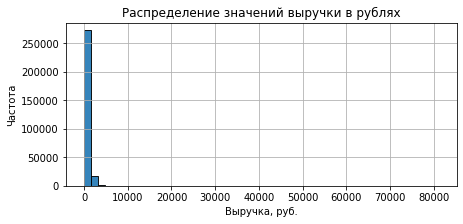

In [30]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим гистограмму с помощью pandas через plot(kind='hist')
df['revenue_rub'].plot(
                kind='hist', # Тип графика - гистограмма
                bins=50, # Устанавливаем количество корзин - всего 50
                alpha=0.90,
                edgecolor='black',
                rot=0, # Градус вращения подписи по оси Х
)

# Настраиваем оформление графика
plt.title('Распределение значений выручки в рублях')
plt.xlabel('Выручка, руб.')
plt.ylabel('Частота')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

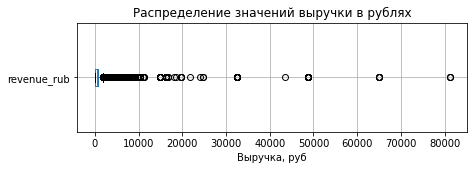

In [31]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 2))

# Строим диаграмму размаха значений в столбце balance
df.boxplot(column='revenue_rub', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение значений выручки в рублях')
plt.xlabel('Выручка, руб')

# Выводим график
plt.show()

In [32]:
df_mask_revenue_rub=df[df['revenue_rub']>1000]
df_mask_revenue_rub.shape[0]


51572

Распределение левостороннее, характеризуется большими значениями справа. Но нельзя говорить об ошибках в данных, просто данные сильно разнятся. Нйдено 51572 значений больше 10000. Есть сервисы с очень высокой выручкой.

In [33]:
procentile_99 = df['revenue_rub'].quantile(0.99)

# Фильтруем датафрейм по 99-му перцентилю
filtered_df = df[df['revenue_rub'] <= procentile_99]

In [34]:
filtered_df['revenue_rub'].describe()

count    287674.000000
mean        518.077881
std         511.942047
min         -90.760002
25%         111.875002
50%         344.019989
75%         788.659973
max        2628.419922
Name: revenue_rub, dtype: float64

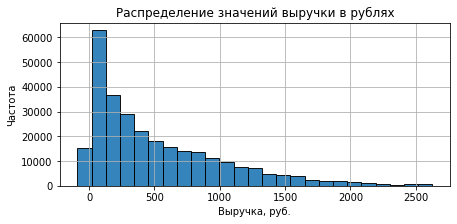

In [35]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим гистограмму с помощью pandas через plot(kind='hist')
filtered_df['revenue_rub'].plot(
                kind='hist', # Тип графика - гистограмма
                bins=25, # Устанавливаем количество корзин - всего 50
                alpha=0.90,
                edgecolor='black',
                rot=0, # Градус вращения подписи по оси Х
)

# Настраиваем оформление графика
plt.title('Распределение значений выручки в рублях')
plt.xlabel('Выручка, руб.')
plt.ylabel('Частота')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

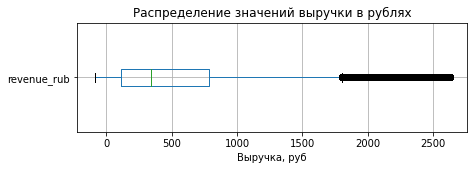

In [36]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 2))

# Строим диаграмму размаха значений в столбце balance
filtered_df.boxplot(column='revenue_rub', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение значений выручки в рублях')
plt.xlabel('Выручка, руб')

# Выводим график
plt.show()

Поскольку очень разнородные данные, то применили к столбцу revenue_rub фильтр, отсавили начения меньше перцентиля 99. Результаты стали более однородные, тенденция распределения сохранена. Также есть выбросы. Но графики стали более читабельны.

In [37]:
otricat=filtered_df[filtered_df['revenue_rub']<0]
display(otricat['revenue_rub'].shape[0]/filtered_df['revenue_rub'].shape[0])

0.001317463517731877

**Изучим столбец `tickets_count`**

In [38]:
df['tickets_count'].describe()

count    290499.000000
mean          2.754402
std           1.170610
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          57.000000
Name: tickets_count, dtype: float64

Среднее значение 2,75 близко к медиане 3, значит распределение нормальное, вершина смещена вправо. Стандартное отклонение 1,17, значит скученность данных в центре. Размах =56, выбросы есть. Правосторонне распределение.

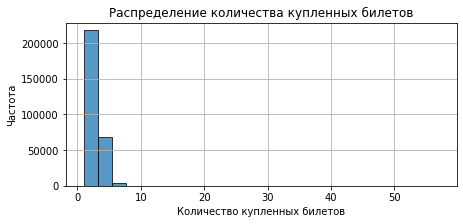

In [39]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим гистограмму с помощью pandas через plot(kind='hist')
df['tickets_count'].plot(
                kind='hist', # Тип графика - гистограмма
                bins=25, # Устанавливаем количество корзин - всего 25
                alpha=0.75,
                edgecolor='black',
                rot=0, # Градус вращения подписи по оси Х
)

# Настраиваем оформление графика
plt.title('Распределение количества купленных билетов')
plt.xlabel('Количество купленных билетов')
plt.ylabel('Частота')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

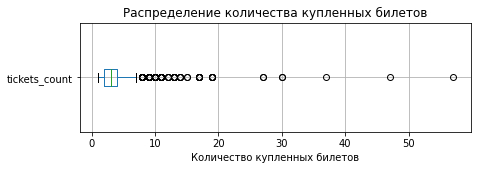

In [40]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 2))

# Строим диаграмму размаха значений в столбце balance
df.boxplot(column='tickets_count', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение количества купленных билетов')
plt.xlabel('Количество купленных билетов')

# Выводим график
plt.show()

Гистограмма и ящик с усами подтверждают сделанные выводы. Выбросы не являются ошибкой.

**Изучим столбец `days_since_prev`**

In [41]:
df['days_since_prev'].describe()

count    268567.000000
mean          3.223508
std          11.352512
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max         148.000000
Name: days_since_prev, dtype: float64

Среднее значение 3,22 больше медианы =0. Не нормальное распределение, вершина смещена влево, преобладают большие значения. Размах 148, выбросы есть. Правостороннее распределение.

In [42]:
df['days_since_prev'].isna().sum()

21932

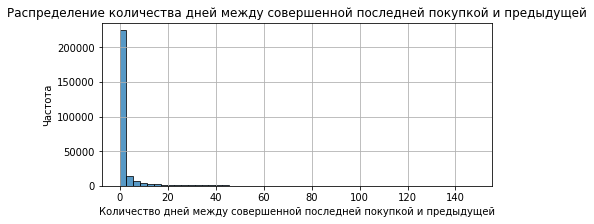

In [43]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим гистограмму с помощью pandas через plot(kind='hist')
df['days_since_prev'].plot(
                kind='hist', # Тип графика - гистограмма
                bins=52, # Устанавливаем количество корзин - всего 25
                alpha=0.75,
                edgecolor='black',
                rot=0, # Градус вращения подписи по оси Х
)

# Настраиваем оформление графика
plt.title('Распределение количества дней между совершенной последней покупкой и предыдущей')
plt.xlabel('Количество дней между совершенной последней покупкой и предыдущей')
plt.ylabel('Частота')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

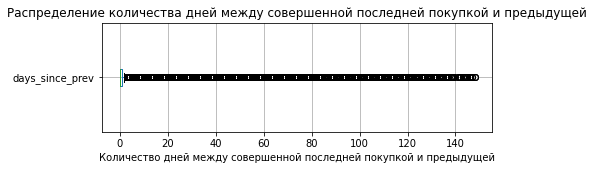

In [44]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 2))

# Строим диаграмму размаха значений в столбце balance
df.boxplot(column='days_since_prev', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение количества дней между совершенной последней покупкой и предыдущей')
plt.xlabel('Количество дней между совершенной последней покупкой и предыдущей')

# Выводим график
plt.show()

Сервисы популярны. Большая часть пользователей 75% сервисов использует их ежедневно. Но есть клиенты, использующие с интервалом от 1 до 148 раз, на их долю приходиться около 19%. Есть с чем работать.

In [45]:
potencial=df[df['days_since_prev']>1]
potencial['days_since_prev'].shape[0]
display(potencial['days_since_prev'].shape[0]/df.shape[0])

0.18640339553664556

**Исследуем revenue**

In [46]:
df['revenue'].describe()

count    290499.000000
mean        625.612366
std        1227.596924
min         -90.760002
25%         116.989998
50%         356.049988
75%         810.130005
max       81174.539062
Name: revenue, dtype: float64

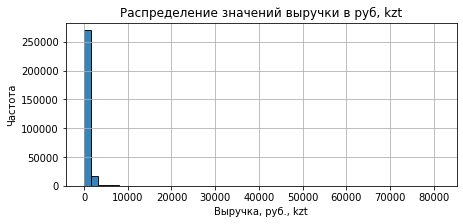

In [47]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим гистограмму с помощью pandas через plot(kind='hist')
df['revenue'].plot(
                kind='hist', # Тип графика - гистограмма
                bins=50, # Устанавливаем количество корзин - всего 50
                alpha=0.90,
                edgecolor='black',
                rot=0, # Градус вращения подписи по оси Х
)

# Настраиваем оформление графика
plt.title('Распределение значений выручки в руб, kzt')
plt.xlabel('Выручка, руб., kzt')
plt.ylabel('Частота')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

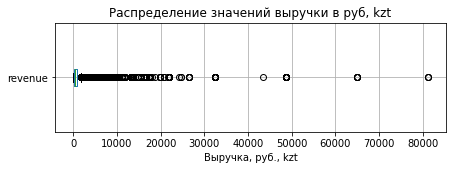

In [48]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 2))

# Строим диаграмму размаха значений в столбце balance
df.boxplot(column='revenue', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение значений выручки в руб, kzt')
plt.xlabel('Выручка, руб., kzt')

# Выводим график
plt.show()

revenue похоже на revenue_rub

**Исследуем event_id**

In [49]:
df['event_id'].describe()

count    290499.000000
mean     438012.762405
std      147428.041291
min        4436.000000
25%      361745.000000
50%      498275.000000
75%      546285.000000
max      592325.000000
Name: event_id, dtype: float64

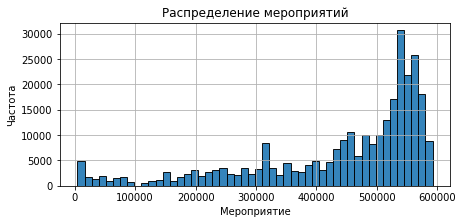

In [50]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим гистограмму с помощью pandas через plot(kind='hist')
df['event_id'].plot(
                kind='hist', # Тип графика - гистограмма
                bins=50, # Устанавливаем количество корзин - всего 50
                alpha=0.90,
                edgecolor='black',
                rot=0, # Градус вращения подписи по оси Х
)

# Настраиваем оформление графика
plt.title('Распределение мероприятий')
plt.xlabel('Мероприятие')
plt.ylabel('Частота')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

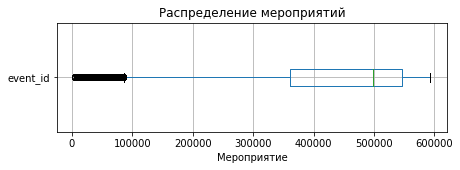

In [51]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 2))

# Строим диаграмму размаха значений в столбце balance
df.boxplot(column='event_id', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение мероприятий')
plt.xlabel('Мероприятие')

# Выводим график
plt.show()

**Исследуем order_id**

In [52]:
df['order_id'].describe()

count    2.904990e+05
mean     4.326091e+06
std      2.497534e+06
min      1.000000e+00
25%      2.163328e+06
50%      4.326279e+06
75%      6.488156e+06
max      8.653108e+06
Name: order_id, dtype: float64

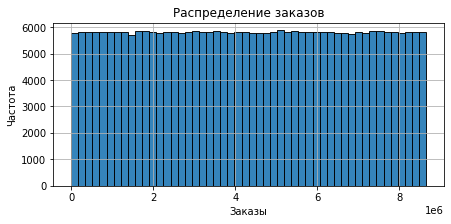

In [53]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим гистограмму с помощью pandas через plot(kind='hist')
df['order_id'].plot(
                kind='hist', # Тип графика - гистограмма
                bins=50, # Устанавливаем количество корзин - всего 50
                alpha=0.90,
                edgecolor='black',
                rot=0, # Градус вращения подписи по оси Х
)

# Настраиваем оформление графика
plt.title('Распределение заказов')
plt.xlabel('Заказы')
plt.ylabel('Частота')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

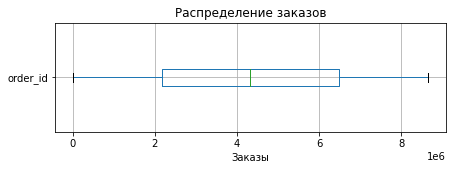

In [54]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 2))

# Строим диаграмму размаха значений в столбце balance
df.boxplot(column='order_id', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение заказов')
plt.xlabel('Заказы')

# Выводим график
plt.show()

In [55]:
df.describe()

,order_id,event_id,revenue,tickets_count,days_since_prev,curs_to_100kzt,revenue_rub
count,2.904990e+05,290499.000000,290499.000000,290499.000000,268567.000000,290499.000000,290499.000000
mean,4.326091e+06,438012.762405,625.612366,2.754402,3.223508,19.188686,555.634521
std,2.497534e+06,147428.041291,1227.596924,1.170610,11.352512,0.622549,875.594238
min,1.000000e+00,4436.000000,-90.760002,1.000000,0.000000,17.848600,-90.760002
25%,2.163328e+06,361745.000000,116.989998,2.000000,0.000000,18.599100,113.970001
50%,4.326279e+06,498275.000000,356.049988,3.000000,0.000000,19.325600,351.250000
75%,6.488156e+06,546285.000000,810.130005,4.000000,1.000000,19.788401,802.049988
max,8.653108e+06,592325.000000,81174.539062,57.000000,148.000000,20.277300,81174.539062


**Вывод2.2**

1. **Выручка в рублях** (`revenue_rub `) очень разнородные данные. Обнаружены выбросы. Поэтому применили к столбцу revenue_rub фильтр, оставили значения меньше перцентиля 99. Результаты стали более однородные, тенденция распределения сохранена. Также есть выбросы. Но графики стали более читабельны: 

Средняя (медианная) выручка в районе 356 рублей. 75% значений в пределах от -90 до 810р. Есть выбросы, правостороннее распределение. Отрицательная выручка означает наличие убыточных сервисов на данный момент, их доля 0.001317.

2. Количество купленных билетов`tickets_count`. В среднем покупают по 3 билета (медиана 3). Стандартное отклонение 1,17, значит скученность данных в центре. Размах =56, выбросы есть. Правосторонне распределение.
Гистограмма и ящик с усами подтверждают сделанные выводы. Выбросы не являются ошибкой.

3. Количество дней между этой покупкой и предыдущей `days_since_prev`. Сервисы популярны. Большая часть пользователей 75% сервисов использует их ежедневно. Но есть клиенты, использующие сервисы с интервалом от 1 до 148 дней, на их долю приходиться около 19%. Есть с чем работать.

4. `revenue` похоже на `revenue_rub`. `event_id` левостороннее распределение с выбросами слева, т.е. есть более популярные сервисы.
order_id нормальное распределение.


<div class="alert alert-info">Убираем отрицательные значения выручки, чтобы не завышать количество валидных транзакций на пользователя.  </div>

In [56]:
df_otr=df[df['revenue_rub']<0]
share_otr=len(df_otr)/len(df)
display(share_otr)

0.0013046516511244445

In [160]:
q99=df['revenue_rub'].quantile(0.99)
df_all_filter=df[(df['revenue_rub']<q99) & (df['revenue_rub']>0)]
df_all_filter_len=df_all_filter.shape[0]
deleted=df.shape[0]-df_all_filter.shape[0]
share_deleted=deleted/len(df)
display(f'Удалено записей: {deleted} ',
      f' Доля удаленных записей: {share_deleted} ',
      f' Количество записей в датафрейме осталось: {df_all_filter_len}')

'Удалено записей: 2817 '

' Доля удаленных записей: 0.01000390638872119 '

' Количество записей в датафрейме осталось: 278773'

Исследуем датафрейм df_all_filter['revenue_rub'] на аномалии и выбросы

In [58]:
df_all_filter['revenue_rub'].describe()

count    281590.000000
mean        527.575806
std         509.067169
min           0.020000
25%         122.610001
50%         358.079987
75%         796.414993
max        2627.000000
Name: revenue_rub, dtype: float64

Нашла значение процентиля Q81, чтобы посмотреть аномалии в этом месте на гистограмме распределения.

In [59]:
# Значение Q81 
q81=df['revenue_rub'].quantile(0.81)
q81

964.6400146484375

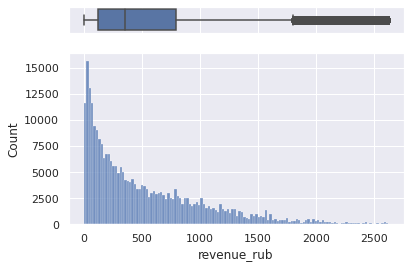

In [60]:
sns.set_theme(style="darkgrid")
 
# creating a figure composed of two matplotlib.Axes objects (ax_box and ax_hist)
f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .99)})
 
# assigning a graph to each ax
sns.boxplot(x=df_all_filter['revenue_rub'], orient="h", ax=ax_box)
sns.histplot(data=df_all_filter['revenue_rub'], ax=ax_hist)

# Remove x axis name for the boxplot
ax_box.set(xlabel='')
plt.show()

**!!!** Переименовали датафрейм **df_all_filter** в **df** для более короткого имени, с которым удобнее работать. **Далее проводим исследование в новом датафрейме df  !!!**

In [61]:
df=df_all_filter.copy()

<div class="alert alert-info">
    
На долю отрицательных значений приходится **0,0013%** .

Поскольку очень разнородные данные, то применим к столбцу revenue_rub фильтр, отсавили значения меньше перцентиля **99** и значения выручки **>0**. Результаты стали более однородные, тенденция распределения сохранена. Также есть выбросы. Но графики стали более читабельны.

Удалено из датафрейма **df 8909** (**0.03**) записей!!!
    
В датафрейме **df 281590** записей.
</div>

---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


Отсортировали датафрейм по времени совершения заказа `order_ts`

In [62]:
df_sort=df.sort_values(by='order_ts')

In [63]:
# Расчёт интервала между заказами в секундах
df_sort['hours_order_ts'] = (
    df_sort.groupby('user_id')['order_ts']
    .diff()  # разница между текущей и предыдущей датой
    .dt.total_seconds() / 3600  # преобразуем timedelta в дни
    #.round()  # округляем до целого числа
)

 

In [64]:
df_sort.shape[0]

281590

In [65]:

user_profile = df_sort.groupby(['user_id'], as_index=False).agg({
    'order_dt':['min','max'], 
    'device_type_canonical':'first', # устройство, с которого был сделан первый заказ;
    'region_name':'first',
    'service_name':'first', # первый билетный партнер
    'event_type_main':'first', # жанр первого посещённого мероприятия
    'order_id':'count',
    'revenue_rub':'mean',
    'tickets_count':'mean',
    'hours_order_ts':'mean', # среднее время между заказами в часах
    'days_since_prev':'mean' # среднее время в днях
     
})
display(user_profile.head())

user_id   order_dt            device_type_canonical  \
                          min        max                 first   
0  0002849b70a3ce2 2024-08-20 2024-08-20                mobile   
1  0005ca5e93f2cf4 2024-07-23 2024-10-06                mobile   
2  000898990054619 2024-07-13 2024-10-23                mobile   
3  00096d1f542ab2b 2024-08-15 2024-08-15               desktop   
4  000a55a418c128c 2024-09-29 2024-10-15                mobile   

            region_name   service_name event_type_main order_id  revenue_rub  \
                  first          first           first    count         mean   
0    каменевский регион   край билетов           театр        1  1521.939941   
1    каменевский регион      мой билет        выставки        2   774.010010   
2  североярская область    лови билет!          другое        3   767.213318   
3    каменевский регион   край билетов           театр        1   917.830017   
4      поленовский край  лучшие билеты           театр        2    61.309998   

  tickets_count hours_order_ts days_since_prev  
           mean           mean            mean  
0      4.000000            NaN             NaN  
1      3.000000    1795.327222            75.0  
2      2.666667    1221.760000            51.0  
3      4.000000            NaN             NaN  
4      1.500000     374.831111            16.0

is_two — совершил ли пользователь 2 и более заказа;
is_five — совершил ли пользователь 5 и более заказов.

Для этого, приведём имена столбцов датафрейма user_profile к стилю snake_case, а затем создадим столбцы.

In [66]:
print(user_profile.columns)

MultiIndex([(              'user_id',      ''),
            (             'order_dt',   'min'),
            (             'order_dt',   'max'),
            ('device_type_canonical', 'first'),
            (          'region_name', 'first'),
            (         'service_name', 'first'),
            (      'event_type_main', 'first'),
            (             'order_id', 'count'),
            (          'revenue_rub',  'mean'),
            (        'tickets_count',  'mean'),
            (       'hours_order_ts',  'mean'),
            (      'days_since_prev',  'mean')],
           )


In [67]:
# Создаём список с названиями столбцов и переименовываем столбцы в user_profile
new_columns=[
    'user_id',
    'order_dt_min',
    'order_dt_max',
    'device_type_canonical_first',
    'region_name_first',
    'service_name_first',
    'event_type_main_first',
    'order_id_count',
    'revenue_rub_mean',
    'tickets_count_mean',
    'hours_order_ts_mean',
    'days_since_prev_mean'
    #'is_two' 
     ]

user_profile = user_profile.set_axis(new_columns, axis=1)

In [68]:
# Определяем функцию, которая создаст новый столбец с бинарным признаком в зависимости от наличия данных в другом столбце
def create_is_na(col, arg):
    """
    Функция создаёт новый столбец с бинарным признаком, который указывает
    на наличие данных в столбце. Если в 'order_id_count' значение больше указанного пользователем arg, 
    то в новый столбец заполняем "1", иначе - "0" 
    """
    if col>=arg:
        return 1
    else:
        return 0

In [69]:
 #Создаём столбец is_balance с помощью функции create_is_na
#bank_df['is_balance'] = bank_df['balance'].isna().apply(create_is_na)

#user_profile['is_two2']=user_profile['order_id_count'].apply(create_is_na, arg)

user_profile['is_two'] = user_profile['order_id_count'].apply(create_is_na, args=(2,))
 
user_profile['is_five'] = user_profile['order_id_count'].apply(create_is_na, args=(5,))
 

In [70]:
user_profile.head()

,user_id,order_dt_min,order_dt_max,device_type_canonical_first,region_name_first,service_name_first,event_type_main_first,order_id_count,revenue_rub_mean,tickets_count_mean,hours_order_ts_mean,days_since_prev_mean,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,каменевский регион,край билетов,театр,1,1521.939941,4.000000,NaN,NaN,0,0
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,каменевский регион,мой билет,выставки,2,774.010010,3.000000,1795.327222,75.0,1,0
2,000898990054619,2024-07-13,2024-10-23,mobile,североярская область,лови билет!,другое,3,767.213318,2.666667,1221.760000,51.0,1,0
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,каменевский регион,край билетов,театр,1,917.830017,4.000000,NaN,NaN,0,0
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,поленовский край,лучшие билеты,театр,2,61.309998,1.500000,374.831111,16.0,1,0


Альтернативный способ, без функции
user_profile['is_two'] = (user_profile['order_id_count'] >= 2).astype('int')
user_profile['is_five'] = (user_profile['order_id_count'] >= 5).astype('int')

In [71]:
user_profile.head()

,user_id,order_dt_min,order_dt_max,device_type_canonical_first,region_name_first,service_name_first,event_type_main_first,order_id_count,revenue_rub_mean,tickets_count_mean,hours_order_ts_mean,days_since_prev_mean,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,каменевский регион,край билетов,театр,1,1521.939941,4.000000,NaN,NaN,0,0
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,каменевский регион,мой билет,выставки,2,774.010010,3.000000,1795.327222,75.0,1,0
2,000898990054619,2024-07-13,2024-10-23,mobile,североярская область,лови билет!,другое,3,767.213318,2.666667,1221.760000,51.0,1,0
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,каменевский регион,край билетов,театр,1,917.830017,4.000000,NaN,NaN,0,0
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,поленовский край,лучшие билеты,театр,2,61.309998,1.500000,374.831111,16.0,1,0


---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [72]:
# общее число пользователей в выборке;
user_count=user_profile['user_id'].count()

# среднюю выручку с одного заказа;
revenue_rub_mean=round(user_profile['revenue_rub_mean'].mean(), 2)

#долю пользователей, совершивших 2 и более заказа;
share_of_users2=round(user_profile['is_two'].mean(),2)

#долю пользователей, совершивших 5 и более заказов.
share_of_users5=round(user_profile['is_five'].mean(),2)

display(f'общее число пользователей: {user_count} ',
        f'средняя выручка с одного заказа: {revenue_rub_mean}',
        f'доля пользователей, совершивших 2 и более заказа: {share_of_users2}',
        f'доля пользователей, совершивших 5 и более заказа: {share_of_users5}')

'общее число пользователей: 21694 '

'средняя выручка с одного заказа: 550.8499755859375'

'доля пользователей, совершивших 2 и более заказа: 0.62'

'доля пользователей, совершивших 5 и более заказа: 0.29'

Также изучаем статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

In [73]:
user_profile[['order_id_count','tickets_count_mean','days_since_prev_mean','hours_order_ts_mean']].describe()

,order_id_count,tickets_count_mean,days_since_prev_mean,hours_order_ts_mean
count,21694.000000,21694.000000,13454.000000,13379.000000
mean,12.980087,2.745798,15.915390,381.975897
std,119.679097,0.914596,22.358349,535.937903
min,1.000000,1.000000,0.000000,0.000278
25%,1.000000,2.000000,1.000000,24.663148
50%,2.000000,2.750000,8.000000,195.628507
75%,5.000000,3.090909,20.500000,493.751776
max,9981.000000,11.000000,148.000000,3557.466111


По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

**order_id_count**- общее число заказов.

Среднее значение 13,2 сильно отличается от медианы=2, знавит есть выбросы. Вершина смещена влево, в сторону с меньшими данными. Стандартное отклонение 122,4 означает большой размах значений относительно центра. Размах большой 10251. Правостороннее распределение.

**tickets_count_mean** -  среднее число билетов в заказе
Среднее значение совпадает с медианой. В среднем покупают 2,7 билета. Распределение нормальное. Стандартное отклонение 0,9, на один билет плюс, минус. Правостороннее распределение.

**days_since_prev_mean** - среднее количество дней между покупками
Среднее значение (15,8) почти в 2 раза больше медианы (8), значит есть выбросы, вершина смещена влево к меньшим числам. В среднем, на 22 дня варьируется число дней между покупками (стандартное отлонение 22,2). Правосторонее распределение.

**hours_order_ts_mean** - среднее количество часов между покупками
Тенденция как в поле **days_since_prev_mean**.

**ГРАФИКИ**

**order_id_count**- общее число заказов.

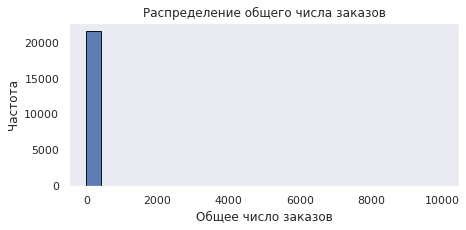

In [74]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим гистограмму с помощью pandas через plot(kind='hist')
user_profile['order_id_count'].plot(
                kind='hist', # Тип графика - гистограмма
                bins=25, # Устанавливаем количество корзин - всего 50
                alpha=0.90,
                edgecolor='black',
                rot=0, # Градус вращения подписи по оси Х
)

# Настраиваем оформление графика
plt.title('Распределение общего числа заказов')
plt.xlabel('Общее число заказов')
plt.ylabel('Частота')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()


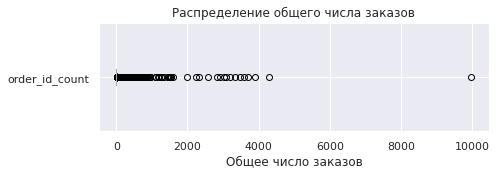

In [75]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 2))

# Строим диаграмму размаха значений в столбце balance
user_profile.boxplot(column='order_id_count', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение общего числа заказов')
plt.xlabel('Общее число заказов')

# Выводим график
plt.show()


Проверим на выбросы методом IQR.

In [76]:
Q1=user_profile['order_id_count'].quantile(0.25)
Q3=user_profile['order_id_count'].quantile(0.75)
IQR=Q3-Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
display(lower_bound, upper_bound) 


-5.0

11.0

Таким образом, для столбца `order_id_count` выбросами являются заказы, больше 11. 

Однако, по нашему мнению, чем больше и дольше клиент пользуется сервисами, тем лучше. Поэтому верхнюю границу, в 11 заказов, считаем нормальной. Но, учитывая, что поле `order_id_count` действительно очень неоднородное, то применим фильтрацию и оставим записи <=0.95 процентиля.

In [77]:
p95 = user_profile['order_id_count'].quantile(0.95)
print(f"95-й перцентиль: {p95}")

95-й перцентиль: 31.0


<Figure size 504x216 with 0 Axes>

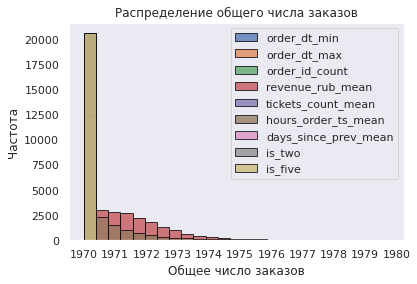

In [78]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим гистограмму с помощью pandas через plot(kind='hist')
user_profile[user_profile['order_id_count']<=32].plot(
                kind='hist', # Тип графика - гистограмма
                bins=25, # Устанавливаем количество корзин - всего 50
                alpha=0.75,
                edgecolor='black',
                rot=0, # Градус вращения подписи по оси Х
)

# Настраиваем оформление графика
plt.title('Распределение общего числа заказов')
plt.xlabel('Общее число заказов')
plt.ylabel('Частота')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

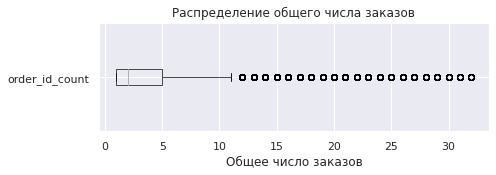

In [79]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 2))

# Строим диаграмму размаха значений в столбце balance
user_profile[user_profile['order_id_count']<=32].boxplot(column='order_id_count', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение общего числа заказов')
plt.xlabel('Общее число заказов')

# Выводим график
plt.show()

In [80]:
count_32=user_profile[user_profile['order_id_count']>32].shape[0]

display(f"Количество и доля записей для удаления: {count_32, count_32/user_profile['order_id_count'].shape[0]}")

'Количество и доля записей для удаления: (1051, 0.048446575089886604)'

In [81]:
user_profile[user_profile['order_id_count'] < 32]['order_id_count'].describe()
 

count    20621.000000
mean         4.029727
std          5.078180
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max         31.000000
Name: order_id_count, dtype: float64

Для столбца `order_id_count` посчитали 0.95 процентиль и выяснили, что 95% значений находятся до 32 заказов. Отброшено 1068  записей, это 5% датафрейма user_profile. 
Врезультате примененного фильтра `user_profile[user_profile['order_id_count']>32]` получили более однородное распределение, представленное и на графиках и описательными статистиками.

Среднее количество заказов 2 (по медиане). Выбросы присутствуют. Стандартное отклонение 5. Правосторонее распределение. 

**tickets_count_mean** -  среднее число билетов в заказе

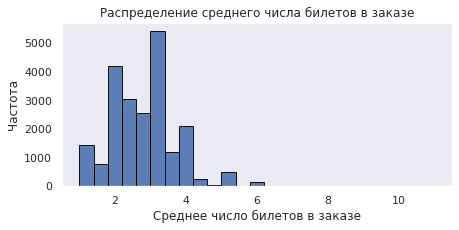

In [82]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим гистограмму с помощью pandas через plot(kind='hist')
user_profile['tickets_count_mean'].plot(
                kind='hist', # Тип графика - гистограмма
                bins=25, # Устанавливаем количество корзин - всего 50
                alpha=0.90,
                edgecolor='black',
                rot=0, # Градус вращения подписи по оси Х
)

# Настраиваем оформление графика
plt.title('Распределение среднего числа билетов в заказе')
plt.xlabel('Среднее число билетов в заказе')
plt.ylabel('Частота')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

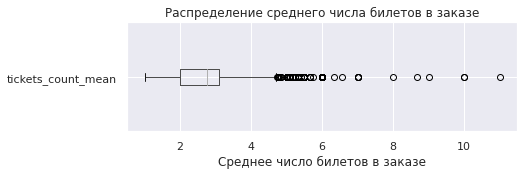

In [83]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 2))

# Строим диаграмму размаха значений в столбце balance
user_profile.boxplot(column='tickets_count_mean', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение среднего числа билетов в заказе')
plt.xlabel('Среднее число билетов в заказе')

# Выводим график
plt.show()


Гистограмма и ящик с усами подтверждают данные описательных статистик. Выбросы есть, но не считаю необхомимым фильтровать записи, поскольку билеты могут покупать и на групповые мероприятия.

**days_since_prev_mean** - среднее количество дней между покупками

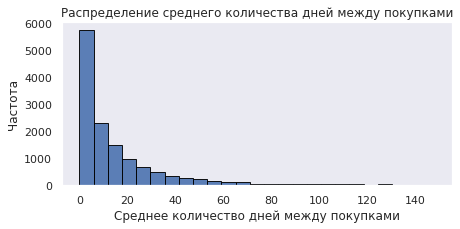

In [84]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим гистограмму с помощью pandas через plot(kind='hist')
user_profile['days_since_prev_mean'].plot(
                kind='hist', # Тип графика - гистограмма
                bins=25, # Устанавливаем количество корзин - всего 50
                alpha=0.90,
                edgecolor='black',
                rot=0, # Градус вращения подписи по оси Х
)

# Настраиваем оформление графика
plt.title('Распределение среднего количества дней между покупками')
plt.xlabel('Среднее количество дней между покупками')
plt.ylabel('Частота')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

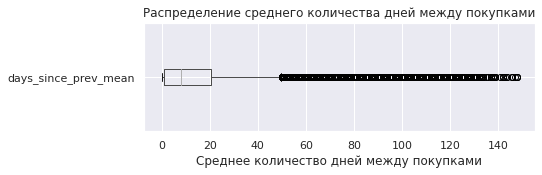

In [85]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 2))

# Строим диаграмму размаха значений в столбце balance
user_profile.boxplot(column='days_since_prev_mean', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение среднего количества дней между покупками')
plt.xlabel('Среднее количество дней между покупками')

# Выводим график
plt.show()


In [86]:
p95=user_profile['days_since_prev_mean'].quantile(0.95)
p95

61.5

In [87]:
count_61=user_profile[user_profile['days_since_prev_mean']>61].shape[0]
display(count_61, count_61/user_profile['days_since_prev_mean'].shape[0])

678

0.03125288098091638

Гистограмма и ящик с усами подтверждают данные описательных статистик. Выбросы есть.

**Применим фильтр на записи и исключим записи из user_profile, где количество заказов больше 32 дальнейшее исследование будем проводить без них!!!**

In [88]:
user_profile=user_profile[user_profile['order_id_count']<=32]

In [89]:
user_profile.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 20643 entries, 0 to 21693
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   user_id                      20643 non-null  object        
 1   order_dt_min                 20643 non-null  datetime64[ns]
 2   order_dt_max                 20643 non-null  datetime64[ns]
 3   device_type_canonical_first  20643 non-null  object        
 4   region_name_first            20643 non-null  object        
 5   service_name_first           20643 non-null  object        
 6   event_type_main_first        20643 non-null  object        
 7   order_id_count               20643 non-null  int64         
 8   revenue_rub_mean             20643 non-null  float32       
 9   tickets_count_mean           20643 non-null  float64       
 10  hours_order_ts_mean          12328 non-null  float64       
 11  days_since_prev_mean         12403 non-nu

In [90]:
user_profile[['order_id_count','tickets_count_mean','days_since_prev_mean','hours_order_ts_mean']].describe()

,order_id_count,tickets_count_mean,days_since_prev_mean,hours_order_ts_mean
count,20643.000000,20643.000000,12403.000000,12328.000000
mean,4.059536,2.746273,17.085325,410.115868
std,5.156874,0.935557,22.904255,549.143543
min,1.000000,1.000000,0.000000,0.000278
25%,1.000000,2.000000,1.000000,23.799931
50%,2.000000,2.750000,9.461538,227.039672
75%,5.000000,3.166667,22.250000,534.502639
max,32.000000,11.000000,148.000000,3557.466111


In [91]:
user_profile.describe()

,order_id_count,revenue_rub_mean,tickets_count_mean,hours_order_ts_mean,days_since_prev_mean,is_two,is_five
count,20643.000000,20643.000000,20643.000000,12328.000000,12403.000000,20643.000000,20643.000000
mean,4.059536,552.759216,2.746273,410.115868,17.085325,0.597200,0.252337
std,5.156874,438.594513,0.935557,549.143543,22.904255,0.490473,0.434364
min,1.000000,0.070000,1.000000,0.000278,0.000000,0.000000,0.000000
25%,1.000000,210.389999,2.000000,23.799931,1.000000,0.000000,0.000000
50%,2.000000,467.116150,2.750000,227.039672,9.461538,1.000000,0.000000
75%,5.000000,785.510834,3.166667,534.502639,22.250000,1.000000,1.000000
max,32.000000,2624.810059,11.000000,3557.466111,148.000000,1.000000,1.000000


**Вывод 3.1 и3.2**

Создан профиль пользователя в датафрейме **user_profile**


- общее число пользователей: 21933 
- средняя выручка с одного заказа: 574.02001953125
- доля пользователей, совершивших 2 и более заказа: 0.62
- доля пользователей, совершивших 5 и более заказа: 0.29

Данные в полях `order_id_count`,`tickets_count_mean`,`days_since_prev_mean` разнородны и содержат выбросы.
Поэтому было решено отфильтровать датафрейм **user_profile** на уровне 0.95 процентиля по полю `order_id_count`. Из выборки исключили **1068** запией (5% от датафрейма user_profile).

Пересчет описательных статистик позволил получить более однородные данные. Выбросы присутствуют, поэтому смотрим на медианные значения.

Итак, средний пользователь сервисов:  совершает два заказа через 9 дней. Покупается 3 билета.

---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


In [92]:
user_profile.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 20643 entries, 0 to 21693
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   user_id                      20643 non-null  object        
 1   order_dt_min                 20643 non-null  datetime64[ns]
 2   order_dt_max                 20643 non-null  datetime64[ns]
 3   device_type_canonical_first  20643 non-null  object        
 4   region_name_first            20643 non-null  object        
 5   service_name_first           20643 non-null  object        
 6   event_type_main_first        20643 non-null  object        
 7   order_id_count               20643 non-null  int64         
 8   revenue_rub_mean             20643 non-null  float32       
 9   tickets_count_mean           20643 non-null  float64       
 10  hours_order_ts_mean          12328 non-null  float64       
 11  days_since_prev_mean         12403 non-nu

In [93]:
user_profile.head()

,user_id,order_dt_min,order_dt_max,device_type_canonical_first,region_name_first,service_name_first,event_type_main_first,order_id_count,revenue_rub_mean,tickets_count_mean,hours_order_ts_mean,days_since_prev_mean,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,каменевский регион,край билетов,театр,1,1521.939941,4.000000,NaN,NaN,0,0
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,каменевский регион,мой билет,выставки,2,774.010010,3.000000,1795.327222,75.0,1,0
2,000898990054619,2024-07-13,2024-10-23,mobile,североярская область,лови билет!,другое,3,767.213318,2.666667,1221.760000,51.0,1,0
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,каменевский регион,край билетов,театр,1,917.830017,4.000000,NaN,NaN,0,0
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,поленовский край,лучшие билеты,театр,2,61.309998,1.500000,374.831111,16.0,1,0


Сгруппируйте пользователей:
по типу их первого мероприятия;
по типу устройства, с которого совершена первая покупка;
по региону проведения мероприятия из первого заказа;
по билетному оператору, продавшему билеты на первый заказ.

In [94]:
for col in ['event_type_main_first', 'device_type_canonical_first', 'region_name_first', 'service_name_first']:
    grouped = user_profile.groupby(col)['user_id'].count()
    sorted_grouped = grouped.sort_values(ascending=False)
    total_users = user_profile['user_id'].nunique()

    # Добавляем столбец с долями  в Series
    percentages = (grouped / total_users * 100).round(1)  
    sorted_percentages = percentages.sort_index()  # сортируем по тому же порядку, что и grouped

    print(f"\n{'='*60}")
    print(f"Количество и доля пользователей по {col}:")
    print('='*60)

    for category in sorted_grouped.index:  # идём по индексам — категориям
        count = sorted_grouped[category]
        share = sorted_percentages[category]  # берём долю для той же категории
        print(f"{category:<30} : {count:>8} ({share:>5.1f}%)")


Количество и доля пользователей по event_type_main_first:
концерты                       :     9238 ( 44.8%)
другое                         :     4998 ( 24.2%)
театр                          :     4088 ( 19.8%)
стендап                        :     1080 (  5.2%)
спорт                          :      741 (  3.6%)
выставки                       :      402 (  1.9%)
ёлки                           :       96 (  0.5%)

Количество и доля пользователей по device_type_canonical_first:
mobile                         :    17131 ( 83.0%)
desktop                        :     3512 ( 17.0%)

Количество и доля пользователей по region_name_first:
каменевский регион             :     6699 ( 32.5%)
североярская область           :     3622 ( 17.5%)
широковская область            :     1195 (  5.8%)
озернинский край               :      664 (  3.2%)
малиновоярский округ           :      517 (  2.5%)
травяная область               :      441 (  2.1%)
светополянский округ           :      440 (  2.1%)
шаныр

Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?
**Задача 4.1.1. Изучите распределение пользователей по признакам.**

Пользователи по сегментам распределены неравномерно:
- по типу первого мероприятия, пользователи больше посещают: концетры (44.4%), другое (24.8%) и театры (19,6%)
- большая часть заказов впервые осуществляется с мобильного устройстава(mobile 82.9%), стационарные (desktop 17%), что практически в 5 раз меньше mobile
- регионами-лидерами по использованию сервиов являются: каменевский регион (32,8%), североярская область (17,2%)
- самыми популярными билетными операторами, продавшими билеты на первый заказ, являются: билеты без проблем (23,9%), мой билет (13,8%), лови билет! (13%), билеты в руки (11,6%) и облачко (10%).

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---



Доля пользователей, совершивших два и более заказа, и количество по event_type_main_first:
                           mean  count
event_type_main_first                 
выставки               0.631841    402
театр                  0.619618   4088
концерты               0.602836   9238
стендап                0.595370   1080
другое                 0.576030   4998
спорт                  0.534413    741


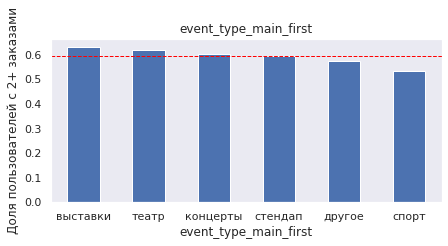


Доля пользователей, совершивших два и более заказа, и количество по device_type_canonical_first:
                                 mean  count
device_type_canonical_first                 
desktop                      0.619021   3512
mobile                       0.592727  17131


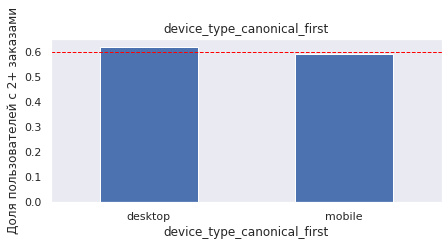


Доля пользователей, совершивших два и более заказа, и количество по region_name_first:
                               mean  count
region_name_first                         
шанырский регион           0.667447    427
горицветская область       0.646552    232
светополянский округ       0.640909    440
речицкий регион            0.636872    179
берёзовская область        0.633663    101
широковская область        0.633473   1195
ветренский регион          0.628378    148
североярская область       0.624517   3622
речиновская область        0.622951    427
заречная область           0.613757    189
каменевский регион         0.603523   6699
травяная область           0.598639    441
каменноозёрный край        0.592233    103
солнечноземская область    0.589286    280
яблоневская область        0.581454    399
верхоречная область        0.575342    365
тепляковская область       0.574675    308
малиновая область          0.572816    103
солнечнореченская область  0.569930    286
зоринский

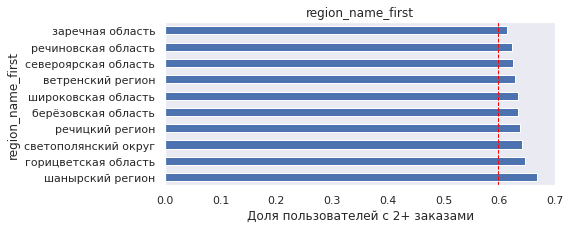


Доля пользователей, совершивших два и более заказа, и количество по service_name_first:
                            mean  count
service_name_first                     
show_ticket             0.645161    155
край билетов            0.641892    444
дом культуры            0.633721    344
мир касс                0.623762    202
весь в билетах          0.613086   1238
билеты в руки           0.609595   2418
прачечная               0.603261    552
облачко                 0.602342   2135
лучшие билеты           0.597173   1132
лови билет!             0.596816   2701
тебе билет!             0.594684    301
быстробилет             0.592593    162
мой билет               0.591638   2870
за билетом!             0.582915    199
билеты без проблем      0.582236   4785
городской дом культуры  0.580189    212
яблоко                  0.517799    309


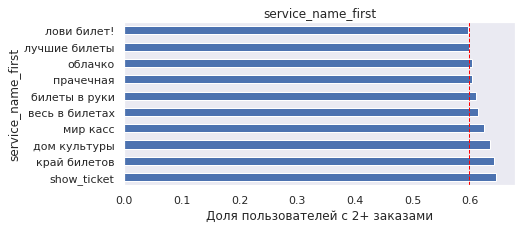

In [95]:
for col in ['event_type_main_first', 'device_type_canonical_first', 'region_name_first', 'service_name_first']:
    grouped = user_profile.groupby(col)
    share = grouped['is_two'].agg(['mean','count'])
    sorted_share=share[share['count']>100].sort_values('mean', ascending=False) # убираем записи с малым числом пользователей, чтобы доли были достоверными   
          
    print(f"\n{'='*60}")
    print(f"Доля пользователей, совершивших два и более заказа, и количество по {col}:")
    print('='*60)
    print(sorted_share)

    i=0
    for category in sorted_share.index:  # идём по индексам — категориям]
        i=i+1 # счетчик категорий
       
    if i<10:
        plt.figure(figsize=(7, 3))
        # Строим график напрямую по share — без value_counts
        sorted_share['mean'].plot(
            kind='bar',
            rot=0,
            legend=False,
            title=f'{col}'
    )
        # Рассчитываем среднее значение по доле нелояльных клиентов
        mean_is_two_share = user_profile['is_two'].mean()
        # Наносим на график линию с средним значением доли нелояльных клиентов
        plt.axhline(mean_is_two_share, # Данные, по которым строится линия
            color='red', # Цвет линии
            linestyle='--', # Стиль линии
            linewidth=1, # Ширина линии
            label=f'Доля нелояльных клиентов {round(mean_is_two_share,4)}')

        plt.xlabel(f'{col}')
        plt.ylabel('Доля пользователей с 2+ заказами')  # Уточняем подпись — это доля, а не количество заказов
        plt.grid()
        plt.show()
    else:
        # Создаём контейнер графика matplotlib и задаём его размер
        plt.figure(figsize=(7, 3))
        # Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
        sorted_share['mean'].head(10).plot(
            kind='barh', # Тип графика - столбчатая диаграмма
            rot=0, # Градус вращения подписи по оси Х
            legend=False, # Выключаем легенду
            title=f'{col}'
        )
        
        # Рассчитываем среднее значение по доле нелояльных клиентов
        mean_is_two_share = user_profile['is_two'].mean()
        # Наносим на график линию с средним значением доли нелояльных клиентов
        plt.axvline(mean_is_two_share, # Данные, по которым строится линия
            color='red', # Цвет линии
            linestyle='--', # Стиль линии
            linewidth=1, # Ширина линии
            label=f'Доля нелояльных клиентов {round(mean_is_two_share,4)}')
        
        # Настраиваем оформление графика
        plt.xlabel('Доля пользователей с 2+ заказами')
        plt.ylabel(f'{col}')
        # Добавляем сетку графика
        plt.grid()
        # Выводим график
        plt.show()

**Вывод по задаче 4.1.2. Проанализируйте возвраты пользователей:**

Чаще возвращаются на Яндекс Афишу следующие сегменты пользователей:

- для сегмента **"по типу первого мероприятия"**, поле `event_type_main_first`, чаще возвращаются на мероприятия: выставки, театр, концерты стендап и другое. Успешными "точками входа" являются выставки (0,626) и театры (0,620);
- для сегмента **по типу устройства**, поле `device_type_canonical_first`, чаще возвращаются те, кто заказывал со **стационарного** устройства (доля 0,62). Это и есть "точка входа";
- для сегмента **регион-лидер**, поле `region_name_first`, "точками входа", самыми успешными TOP-10 по привлечению регионами стали: шанырский регион (0,66), светополянский округ (0,64), широковская область (0,636), горицветская область (0,63), речицкий регион (0,63), берёзовская область (0,62), ветренский регион (0,62), североярская область (0,62), речиновская область (0,62) и заречная область (0,61);
- для сегмента **билетный оператор**, поле `service_name_first`, "точками входа", самыми быстрорастущими опрераторами стали: край билетов (0,64), show_ticket (0,64), дом культуры (0,63), мир касс (0,62), весь в билетах (0,61), билеты в руки (0,61), прачечная (0,60) и облачко (0,60).


---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

**Проверка гипотезы 1.**

**Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.

Гипотеза 1 подтверждается. Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: каждый второй возвращается на мероприятие (доля возврата от 0,54 до 0,63). 

Например, пользователи, которые совершили первый заказ на спортивные мероприятия (доля впервые привлеченных 3,7% (см. результаты задачи 4.1.1) ), совершают повторный заказ чаще (доля возврата 0,54 (см. задачу 4.1.2)), чем пользователи, оформившие свой первый заказ на концерты (0,44 см. результаты задачи 4.1.1).

**Проверка гипотезы 2.**

**Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

Гипотеза 2 **не подтверждается**. В регионах, где больше всего пользователей не самая высокая доля повторных заказов. Самая высокая доля повторных заказов (зад. 4.1.2), в регионах, где доля пользователей ниже 5% (зад. 4.1.1).

Например, лидерами по повторным заказам (доли 0,66 и 0,64 соответственно) являются: шанырский регион и светополянский округ. Но пользователей в них зарегистрировано 470 и 441. В то время, как каменевский регион,  с числом пользователей 6841, находится на 11 месте (с доля 0,61).

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


Строим сравнительную гистограмму распределения средней выручки с билета (revenue_rub_mean):
для пользователей, совершивших один заказ.

In [96]:
user_profile['revenue_rub_mean'].describe()

count    20643.000000
mean       552.759216
std        438.594513
min          0.070000
25%        210.389999
50%        467.116150
75%        785.510834
max       2624.810059
Name: revenue_rub_mean, dtype: float64

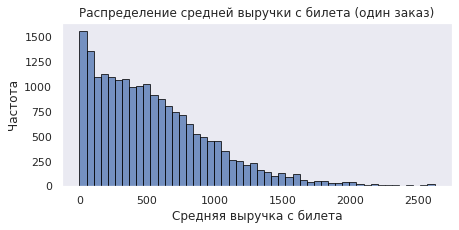

In [97]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим гистограмму с помощью pandas через plot(kind='hist')
user_profile['revenue_rub_mean'].plot(
                kind='hist', # Тип графика - гистограмма
                bins=50, # Устанавливаем количество корзин - всего 25
                alpha=0.75,
                edgecolor='black',
                rot=0, # Градус вращения подписи по оси Х
)

# Настраиваем оформление графика
plt.title('Распределение средней выручки с билета (один заказ)')
plt.xlabel('Средняя выручка с билета')
plt.ylabel('Частота')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

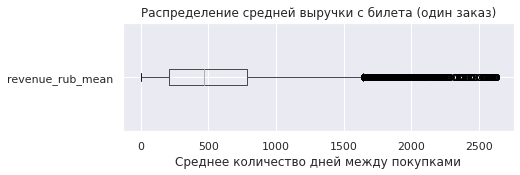

In [98]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 2))

# Строим диаграмму размаха значений в столбце balance
user_profile.boxplot(column='revenue_rub_mean', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение средней выручки с билета (один заказ)')
plt.xlabel('Среднее количество дней между покупками')

# Выводим график
plt.show()

In [99]:
user_profile['revenue_rub_mean'].quantile(0.99)

1972.25

<Figure size 504x216 with 0 Axes>

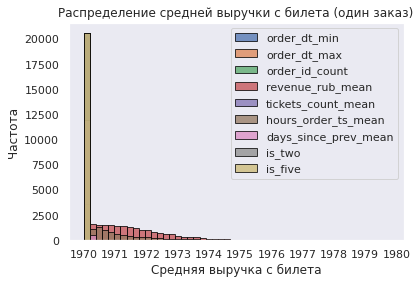

In [100]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим гистограмму с помощью pandas через plot(kind='hist')
user_profile[user_profile['revenue_rub_mean']<2313].plot(
                kind='hist', # Тип графика - гистограмма
                bins=50, # Устанавливаем количество корзин - всего 50
                alpha=0.75,
                edgecolor='black',
                rot=0, # Градус вращения подписи по оси Х
)

# Настраиваем оформление графика
plt.title('Распределение средней выручки с билета (один заказ)')
plt.xlabel('Средняя выручка с билета')
plt.ylabel('Частота')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

In [101]:
user_profile['revenue_rub_mean']

0        1521.939941
1         774.010010
2         767.213318
3         917.830017
4          61.309998
            ...     
21688      50.514999
21689     688.043335
21690     850.994995
21692     661.530029
21693     802.250000
Name: revenue_rub_mean, Length: 20643, dtype: float32

Постройте сравнительные гистограммы распределения средней выручки с билета (avg_revenue_rub):
для вернувшихся пользователей, совершивших 2 и более заказа.

Рекомендация:

Используйте одинаковые интервалы (bins) и прозрачность (alpha), чтобы визуально сопоставить распределения.
Задайте параметру density значение True, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

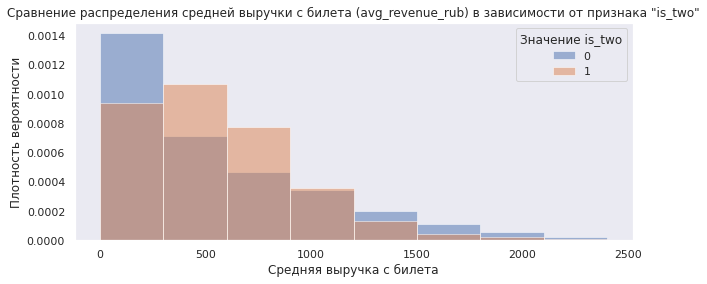

In [102]:
# Строим гистограмму распределения значений средней выручки с клиента revenue_rub_mean в зависимости от признака "is_two"
# Создаём фигуру графика
plt.figure(figsize=(10, 4))

# Находим минимальное и максимальное значения
min_value = user_profile['revenue_rub_mean'].min()
max_value = user_profile['revenue_rub_mean'].max()

# Строим гистограммы для каждого значения churn
for i in user_profile['is_two'].unique():
    # Фильтруем данные по значению столбца churn
    user_profile.loc[user_profile['is_two'] == i,'revenue_rub_mean'].plot(
        kind='hist',
        density=True,
        bins=range(int(min_value), int(max_value)+1, 300),
        alpha=0.5,
        label=f'{i}',
        legend=True
    )

# Настраиваем внешний вид графика и выводим его на экран
plt.title('Сравнение распределения средней выручки с билета (avg_revenue_rub) в зависимости от признака "is_two"')
plt.xlabel('Средняя выручка с билета')
plt.ylabel('Плотность вероятности')
plt.legend(title='Значение is_two', loc='upper right')
plt.grid(alpha=0.3)
plt.show()

На графике видно, что распределение для вернувшихся пользователей сдвинуто вправо, по отношению к тем, кто не делал второй заказ. Значит, второй заказ предпочитают пользователи с более высоким чеком (более богатые) от 300 до 600 руб.

Ниже построен тот же график для перцентиля 0,99, более наглядный.

In [103]:
#new_useer_profile=user_profile[user_profile['revenue_rub_mean']<2313]

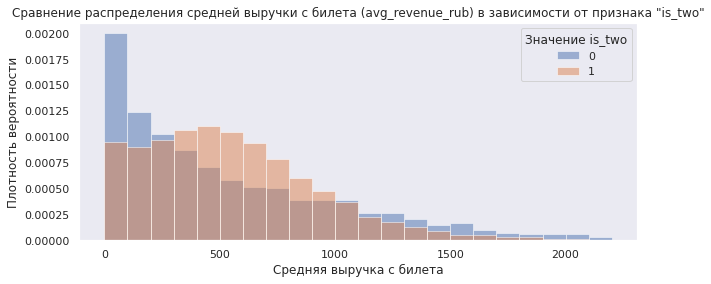

In [104]:
# Строим гистограмму распределения значений средней выручки с клиента revenue_rub_mean в зависимости от признака "is_two"
# Создаём фигуру графика
plt.figure(figsize=(10, 4))

# Находим минимальное и максимальное значения
min_value = new_useer_profile['revenue_rub_mean'].min()
max_value = new_useer_profile['revenue_rub_mean'].max()

# Строим гистограммы для каждого значения is_two
for i in new_useer_profile['is_two'].unique():
    # Фильтруем данные по значению столбца is_two
    new_useer_profile.loc[new_useer_profile['is_two'] == i,'revenue_rub_mean'].plot(
        kind='hist',
        density=True,
        bins=range(int(min_value), int(max_value)+1, 100),
        alpha=0.5,
        label=f'{i}',
        legend=True
    )

# Настраиваем внешний вид графика и выводим его на экран
plt.title('Сравнение распределения средней выручки с билета (avg_revenue_rub) в зависимости от признака "is_two"')
plt.xlabel('Средняя выручка с билета')
plt.ylabel('Плотность вероятности')
plt.legend(title='Значение is_two', loc='upper right')
plt.grid(alpha=0.3)
plt.show()

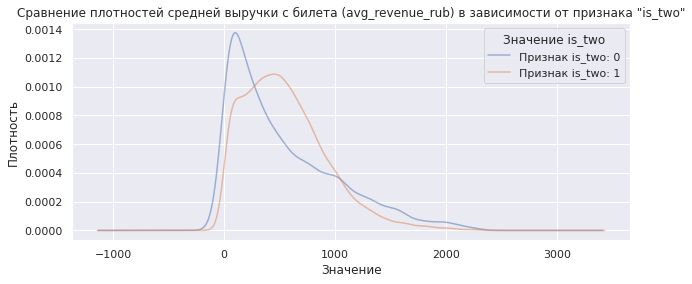

In [105]:
# Строим гистограмму распределения средней выручки с клиента revenue_rub_mean в зависимости от признака "is_two"
column = 'revenue_rub_mean'

# Создаём фигуру графика
plt.figure(figsize=(10, 4))

# Строим гистограммы для каждого значения is_two
for i in new_useer_profile['is_two'].unique():
    # Фильтруем данные по значению столбца is_two
    new_useer_profile.loc[new_useer_profile['is_two'] == i, column].plot(
        kind='kde',
        alpha=0.5,
        label=f'Признак is_two: {i}',
        legend=True
    )

# Настраиваем внешний вид графика и выводим его на экран
plt.title(f'Сравнение плотностей средней выручки с билета (avg_revenue_rub) в зависимости от признака "is_two"')
plt.xlabel('Значение')
plt.ylabel('Плотность')
plt.legend(title='Значение is_two')
plt.show()

Линия KDE для распределения средней выручки с билета нелояльных клиентов is_two:0 сдвинута влево по отношению к линии KDE для лояльных клиентов is_two:1. При этом линия лояльных клиентов ниже по значению плотности по сравнению с линией нелояльных клиентов. Это может указывать на разброс значений.

Для более детального анализа данных рассчитаем среднее и медианное значения средней выручки с билета для лояльных и нелояльных клиентов:

In [106]:
# Рассчитаем среднее и медианное значения возраста для
# лояльных и нелояльных клиентов
new_useer_profile.groupby('is_two').agg({'revenue_rub_mean':['mean','median']})

revenue_rub_mean            
                   mean      median
is_two                             
0            536.684265  382.419983
1            552.619568  501.077515

Действительно, видны различия в среднем и медиане для разных клиентов. Значит, среднюю выручку с сервисов можно использовать для дальнейшего изучения заказов Яндекс Афиша.

На основе написанного кода создадим функцию для визуализации данных:

In [107]:
def plot_hist(df, column, groupby, title, xlabel, ylabel, binwidth, kde=False):
    '''
    Функция для визуализации распределения значений с учётом категорий и линией KDE.
    Параметры:
    df - датафрейм с данными для анализа.
    column - str, название столбца, значения которого будут отображаться на графике.
    groupby - str, название столбца, по которому будет производиться группировка данных.
    binwidth - int, ширина корзины для гистограммы.
    title - str, заголовок графика.
    xlabel - str, подпись по оси X.
    ylabel - str, подпись по оси Y.
    kde - наложение графика KDE на гистограмму.
    '''

    # Создаём график
    plt.figure(figsize=(7, 3))

    # Находим минимальное и максимальное значения
    min_value = int(df[column].min())
    max_value = round(df[column].max())

    for value in df[groupby].unique():
        # Фильтруем данные по значению столбца churn
        df.loc[df[groupby] == value, column].plot(
            kind='hist',
            density=True,
            bins=range(min_value, max_value+1, binwidth),
            alpha=0.5,
            label=f'{groupby}: {value}',
            legend=True
        )

    for value in df[groupby].unique():
        if kde == True:
            df.loc[df[groupby] == value, column].plot(
                kind='kde',
                label=f'KDE {value}',
            )

    # Настраиваем график
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.xlim(min_value, max_value)

    plt.grid()
    plt.show()

Посмотрим на распределение значений оценочной заработной платы и суммы баланса в зависимости от оттока:

<div style="background-color: #f0f0f0; padding: 10px; border-radius: 5px;">
    

**Вывод по задаче 4.2.1**

В каких диапазонах средней выручки концентрируются пользователи из каждой группы?

- Пользователи, совершающие один заказ, в среднем готовы тратить на сервисы около 370 руб (диапазон от 0 до 370). Данные искажены выбросами.
- Выручка от пользователей, совершающих от двух и более заказов, вырьивуется в диапазоне от 300 до 700 руб, средний чек - 500руб. Выбросы есть, но меньше, по сравнению с группой "0"

Есть ли различия между группами?

- группа, с признаком "0" (один заказ), характеризуется: выбросами, низким средним чеком, кратковременностью эффекта покупки;
= группа, с признаком "1" (2+ заказов), характеризуется: более высоким средним чеком, эффект покупки более длительный по времени, большей численностью пользователлей.
</div>

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


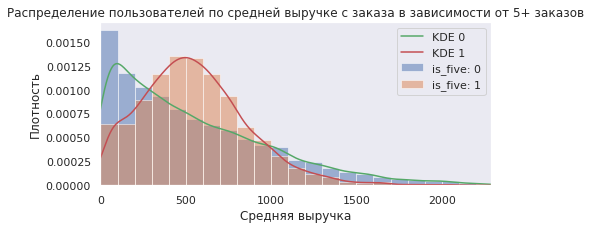

In [108]:
# Построим гистограмму распределения данных и линию KDE  plot_hist
plot_hist(
    df=new_useer_profile,
    column='revenue_rub_mean',
    groupby='is_five',
    binwidth=100,
    title='Распределение пользователей по средней выручке с заказа в зависимости от 5+ заказов',
    xlabel='Средняя выручка',
    ylabel='Плотность',
    kde=True
)

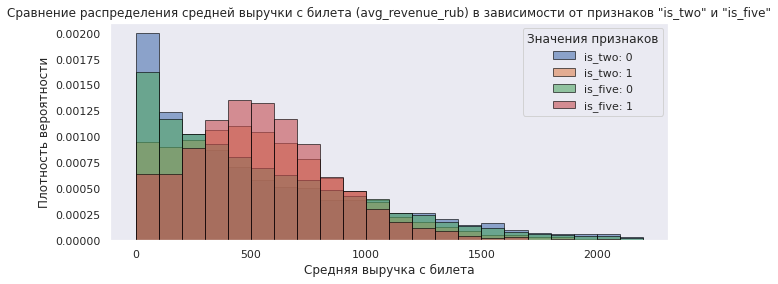

In [109]:
# Строим гистограмму распределения значений средней выручки с клиента revenue_rub_mean
# в зависимости от признаков "is_two" и "is_five"
plt.figure(figsize=(10, 4))

# Находим минимальное и максимальное значения
min_value = new_useer_profile['revenue_rub_mean'].min()
max_value = new_useer_profile['revenue_rub_mean'].max()

# Строим гистограммы для каждого значения is_two и is_five
for col in ['is_two', 'is_five']:  # Перебираем оба признака
    for i in new_useer_profile[col].unique():  # Для каждого уникального значения признака
        new_useer_profile.loc[new_useer_profile[col] == i, 'revenue_rub_mean'].plot(
            kind='hist',
            density=True,
            bins=range(int(min_value), int(max_value) + 1, 100),
            edgecolor='black',
            alpha=0.6,
            label=f'{col}: {i}',  # Подпись с указанием признака и его значения
            legend=True
        )

# Настраиваем внешний вид графика и выводим его на экран
plt.title('Сравнение распределения средней выручки с билета (avg_revenue_rub) в зависимости от признаков "is_two" и "is_five"')
plt.xlabel('Средняя выручка с билета')
plt.ylabel('Плотность вероятности')
plt.legend(title='Значения признаков', loc='upper right')  # Обновляем заголовок легенды
plt.grid(alpha=0.3)
plt.show()

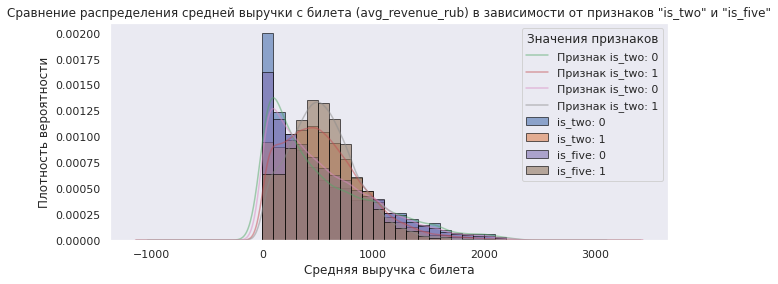

In [110]:
# Строим гистограмму распределения значений средней выручки с клиента revenue_rub_mean
# в зависимости от признаков "is_two" и "is_five"
plt.figure(figsize=(10, 4))
column = 'revenue_rub_mean'

# Находим минимальное и максимальное значения
min_value = new_useer_profile['revenue_rub_mean'].min()
max_value = new_useer_profile['revenue_rub_mean'].max()

# Строим гистограммы для каждого значения is_two и is_five
for col in ['is_two', 'is_five']:  # Перебираем оба признака
    for i in new_useer_profile[col].unique():  # Для каждого уникального значения признака
        new_useer_profile.loc[new_useer_profile[col] == i, 'revenue_rub_mean'].plot(
            kind='hist',
            density=True,
            bins=range(int(min_value), int(max_value) + 1, 100),
            edgecolor='black',
            alpha=0.6,
            label=f'{col}: {i}',  # Подпись с указанием признака и его значения f'KDE {value}'
            legend=True
        )
        
    for i in new_useer_profile['is_two'].unique():
    # Фильтруем данные по значению столбца is_two
        new_useer_profile.loc[new_useer_profile[col] == i, column].plot(
            kind='kde',
            alpha=0.5,
            label=f'Признак is_two: {i}',
            legend=True
        )
        

# Настраиваем внешний вид графика и выводим его на экран
plt.title('Сравнение распределения средней выручки с билета (avg_revenue_rub) в зависимости от признаков "is_two" и "is_five"')
plt.xlabel('Средняя выручка с билета')
plt.ylabel('Плотность вероятности')
plt.legend(title='Значения признаков', loc='upper right')  # Обновляем заголовок легенды
plt.grid(alpha=0.3)
plt.show()

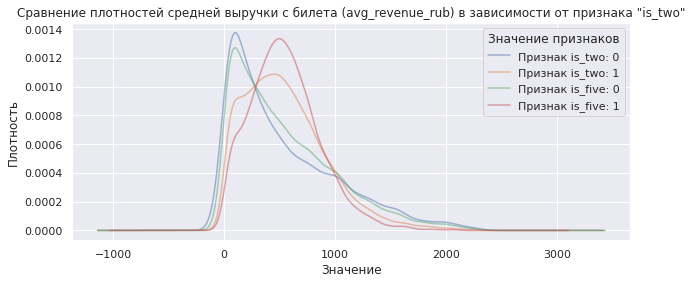

In [111]:
# Строим гистограмму распределения средней выручки с клиента revenue_rub_mean в зависимости от признака "is_two"
column = 'revenue_rub_mean'

# Создаём фигуру графика
plt.figure(figsize=(10, 4))

# Строим гистограммы для каждого значения is_two
for col in ['is_two', 'is_five']:
    for i in new_useer_profile['is_two'].unique():
    # Фильтруем данные по значению столбца is_two
        new_useer_profile.loc[new_useer_profile[col] == i, column].plot(
            kind='kde',
            alpha=0.5,
            label=f'Признак {col}: {i}',
            legend=True
        )

    
# Настраиваем внешний вид графика и выводим его на экран
plt.title(f'Сравнение плотностей средней выручки с билета (avg_revenue_rub) в зависимости от признака "is_two"')
plt.xlabel('Значение')
plt.ylabel('Плотность')
plt.legend(title='Значение признаков')
plt.show()

- линия KDE для распределения средней выручки с билета нелояльных клиентов (is_five: 0) сдвинута влево по отношению к линии KDE для лояльных клиентов (is_five: 1), также как в случае с признаком KDE is_two: 0, но вершина расположена ниже. Диапазоны значений практически совпадают. То есть, в случае заказов 5+, нелояльные пользователи (is_five: 0) тратят также меньше и пределах от 0 до 300; Выбросов меньше.
- линия KDE для распределения средней выручки с билета лояльных клиентов (is_five: 1) сдвинута вправо по отношению к линии KDE для нелояльных клиентов (is_five: 0), также как в случае с признаком KDE is_two: 1, но вершина расположена выше и правее. Значит лояльные клиенты с заказами 5+, тратят в среднем больше, чем лояльные клиенты 2+, в диапазоне от 300 до 800, а средний чек =524 руб.
- вершины линий KDE (is_five: 0) и (is_five: 1) практически на одном уровне, значит разброс значений ниже (практически отсутствует).

In [112]:
# Рассчитаем среднее и медианное значения revenue_rub_mean для
# лояльных и нелояльных пользователей

for col in ['is_two','is_five']:
    display(new_useer_profile.groupby(col).agg({'revenue_rub_mean':['mean','median','count']}))

revenue_rub_mean                   
                   mean      median  count
is_two                                    
0            536.684265  382.419983   8252
1            552.619568  501.077515  12322

revenue_rub_mean                   
                    mean      median  count
is_five                                    
0             545.308105  433.190002  15365
1             548.941711  522.208313   5209

<div style="background-color: #f0f0f0; padding: 10px; border-radius: 5px;">

**Вывод по задаче 4.2.2. Сравните распределение по средней выручке с заказа в двух группах пользователей:**

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?
Различия есть:  характеристики нелояльных групп пользователей (is_five: 0) и (is_two: 0) находятся в диапазоне среднего чека от 0 до 300. Для (is_five: 0) более однородные данные. Диапазон среднего чека для (is_five: 1) выше по сравнению с (is_two: 1) и изменяется от  от 300 до 800. Разброс значений в группе is_five ниже чем в is_two. Клиенты группы is_five: 1 более сегментированы.
</div>

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

tickets_count_mean
Изучаем распределение пользователей по среднему количеству билетов в заказе (avg_tickets_count) и опишем основные наблюдения

In [113]:
user_profile['tickets_count_mean'].describe()

count    20643.000000
mean         2.746273
std          0.935557
min          1.000000
25%          2.000000
50%          2.750000
75%          3.166667
max         11.000000
Name: tickets_count_mean, dtype: float64

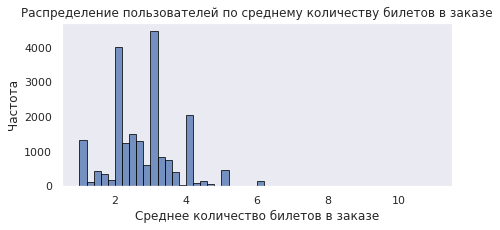

In [114]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим гистограмму с помощью pandas через plot(kind='hist')
user_profile['tickets_count_mean'].plot(
                kind='hist', # Тип графика - гистограмма
                bins=50, # Устанавливаем количество корзин - всего 25
                alpha=0.75,
                edgecolor='black',
                rot=0, # Градус вращения подписи по оси Х
)

# Настраиваем оформление графика
plt.title('Распределение пользователей по среднему количеству билетов в заказе')
plt.xlabel('Среднее количество билетов в заказе')
plt.ylabel('Частота')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

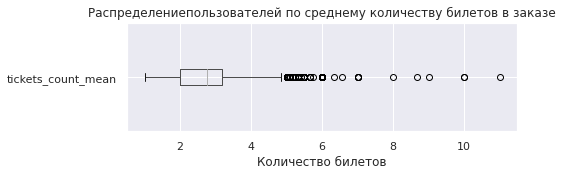

In [115]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 2))

# Строим диаграмму размаха значений в столбце balance
user_profile.boxplot(column='tickets_count_mean', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределениепользователей по среднему количеству билетов в заказе')
plt.xlabel('Количество билетов')

# Выводим график
plt.show()

tickets_count_mean

Распределение близко к нормальному. Преобладают низкие значения. Распределение правостороннее. Присутствуют выбросы. Однако, не можем считать выбросы аномальными значениями, поскольку могут продавать билеты и группам пользователей. Это хорошо. В среднем, покупают около 3 билетов (2,8), от 1 до 3 в 75% случаев. Стандартное отклонение 0,9 билета. Даннные "скучены" у центра.

Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
от 1 до 2 билетов;
от 2 до 3 билетов;
от 3 до 5 билетов;
от 5 и более билетов.

In [116]:
#Создали столбец tickets_group
def categorize(value):
    if value<2:
        return 'от 1 до 2 билетов'
    elif value<3:
        return 'от 2 до 3 билетов'
    elif value<5:
        return 'от 3 до 5 билетов'
    else:
        return 'от 5 и более билетов'



user_profile['tickets_group']=user_profile['order_id_count'].apply(categorize)

Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
совершивших повторные заказы


In [168]:
grouped_tickets = user_profile.groupby('tickets_group')['is_two'].count()
total_users =len(user_profile)
sort_grouped_tickets=grouped_tickets.sort_values(ascending=False)
share_tickets = round((grouped_tickets / total_users) * 100, 1)  # вычисляем долю в процентах
sort_share_tickets=share_tickets.sort_values(ascending=False)

print(f"\n{'='*60}")
print(f"Количество и доля пользователей, совершивших повторные заказы")
print('='*60)

for category in sort_grouped_tickets.index:  # идём по индексам — категориям
    count = grouped_tickets[category]
    share = share_tickets[category]  # берём долю для той же категории
    print(f"{category:<30} : {count:>8} ({share:>5.1f}%)")
 


Количество и доля пользователей, совершивших повторные заказы
от 1 до 2 билетов              :     8315 ( 40.3%)
от 5 и более билетов           :     5209 ( 25.2%)
от 3 до 5 билетов              :     3563 ( 17.3%)
от 2 до 3 билетов              :     3556 ( 17.2%)


<div style="background-color: #f0f0f0; padding: 10px; border-radius: 5px;">

**Вывод по задаче 4.2.3. Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.**

Ответьте на вопросы:

Как распределены пользователи по сегментам — равномерно или сконцентрировано?

- Пользователи, совершившие повторные заказы, распределены не равномерно. Чаще покупают из категории 'от 1 до 2 билетов' (40%) и 'от 5 и более билетов' (25.5%)

    Есть ли сегменты с аномально высокой или низкой долей повторных покупок?
- Сегментов с аномально высокой или низкой долей повторных покупок нет.
- Есть два сегмента с низкой долей повторных покупок в 17.2%: 'от 2 до 3 билетов', 'от 3 до 5 билетов'.
</div>

<div class="alert alert-info"> <b>Комментарии студента:</b> Считаю количество пользователей и долю пользователей совершивших 2 и более заказов: 
</div>

In [170]:
grouped_tickets = user_profile.groupby('tickets_group')['is_two'].count()
total_users =user_profile['is_two'].sum() # Количество пользователей 2+ заказов
sort_grouped_tickets=grouped_tickets.sort_values(ascending=False)
share_tickets = round((grouped_tickets / total_users) * 100, 1)  # вычисляем долю в процентах
sort_share_tickets=share_tickets.sort_values(ascending=False)

print(f"\n{'='*60}")
print(f"Количество и доля пользователей, совершивших повторные заказы")
print('='*60)

for category in sort_grouped_tickets.index:  # идём по индексам — категориям
    count = grouped_tickets[category]
    share = share_tickets[category]  # берём долю для той же категории
    print(f"{category:<30} : {count:>8} ({share:>5.1f}%)")
 



Количество и доля пользователей, совершивших повторные заказы
от 1 до 2 билетов              :     8315 ( 67.4%)
от 5 и более билетов           :     5209 ( 42.3%)
от 3 до 5 билетов              :     3563 ( 28.9%)
от 2 до 3 билетов              :     3556 ( 28.8%)


<div class="alert alert-info"> <b>Комментарии студента:</b> 
**Вывод по задаче 4.2.3. Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.**

Ответьте на вопросы:

Как распределены пользователи по сегментам — равномерно или сконцентрировано?

- Пользователи, совершившие повторные заказы, распределены не равномерно. Чаще покупают из категории 'от 1 до 2 билетов' (67.4%) и 'от 5 и более билетов' (42.3%)

    Есть ли сегменты с аномально высокой или низкой долей повторных покупок?
- Сегментов с аномально высокой или низкой долей повторных покупок нет.
- Есть два сегмента с низкой долей повторных покупок в 29%: 'от 2 до 3 билетов', 'от 3 до 5 билетов'.

</div>

---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


In [118]:
user_profile['day_week_order_dt_min']=user_profile['order_dt_min'].dt.dayofweek

In [119]:
def count_share(grouped, col, title):
    
    '''
    Функция подсчитывает количество и долю записей по указанным столбцам: 
        - по которому будет производиться группировка данных
        - название столбца, к которому применяется групповая операция.
    Параметры:
    grouped - str, название столбца, по которому будет производиться группировка данных.
    col - str, название столбца, к которому применяется групповая операция.
    title - str, заголовок поясняющей надписи.
    
    Пример, вызова функции:
    count_share(grouped='day_week_order_dt_min', col='is_two', title='Количество и доля пользователей по дням недели')
    
    '''
    
    grouped_col = user_profile.groupby(grouped)[col].count()
    total_col = len(user_profile)
    sort_grouped_col=grouped_col.sort_values(ascending=False)
    share_col = round((grouped_col / total_col) * 100, 1)  # вычисляем долю в процентах
    sort_share_col=share_col.sort_values(ascending=False)

    print(f"\n{'='*60}")
    print(f"{title}")
    print('='*60)

    for category in sort_grouped_col.index:  # идём по индексам — категориям
        count = grouped_col[category]
        share = share_col[category]  # берём долю для той же категории
        print(f"{category:<30} : {count:>8} ({share:>5.1f}%)")


In [120]:
count_share(grouped='day_week_order_dt_min', col='is_two', title='Количество и доля пользователей по дням недели, совершивших повторные заказы')


Количество и доля пользователей по дням недели, совершивших повторные заказы
4                              :     3143 ( 15.2%)
5                              :     3099 ( 15.0%)
3                              :     3014 ( 14.6%)
1                              :     3006 ( 14.6%)
2                              :     2956 ( 14.3%)
0                              :     2800 ( 13.6%)
6                              :     2625 ( 12.7%)


In [121]:
grouped_col = user_profile.groupby('day_week_order_dt_min', as_index=False)['is_two'].agg(['sum', 'mean'] )
grouped_col.sort_values('day_week_order_dt_min')

,sum,mean
day_week_order_dt_min,,
0,1716,0.612857
1,1802,0.599468
2,1803,0.609946
3,1759,0.583610
4,1847,0.587655
5,1874,0.604711
6,1527,0.581714


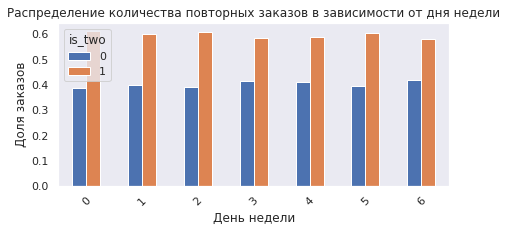

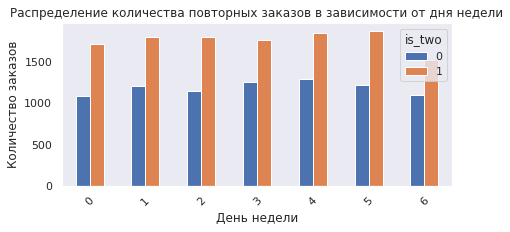

In [122]:
grouped_col = user_profile.groupby('day_week_order_dt_min')['is_two'].value_counts(normalize=True).unstack(fill_value=0)
grouped_col.plot(kind='bar',
               title=f'Распределение количества повторных заказов в зависимости от дня недели',
               legend=True,
               ylabel='Доля заказов',
               xlabel='День недели',
               rot=45,
               figsize=(7, 3))
plt.grid()

# Выводим график
plt.show()

grouped_col = user_profile.groupby('day_week_order_dt_min')['is_two'].value_counts().unstack(fill_value=0)
grouped_col.plot(kind='bar',
               title=f'Распределение количества повторных заказов в зависимости от дня недели',
               legend=True,
               ylabel='Количество заказов',
               xlabel='День недели',
               rot=45,
               figsize=(7, 3))
plt.grid()

# Выводим график
plt.show()

In [123]:
# Задаём функцию для анализа данных
def plot_bar_plot(df, groupby, value, aggfunc, title, ylabel, xlabel):
    '''
    Функция для анализа распределения метрики по признакам:
    df - датафрейм с данными для анализа;
    groupby - str, название столбца для группировки данных;
    value - str, название столбца, значение которого будет агрегироваться;
    aggfunc - str, функция агрегации, которая используется для расчёта;
    title - str, заголовок графика;
    ylabel - str, подпись по оси Y;
    xlabel - str, подпись по оси X.
    '''
    grouped = df.groupby(groupby).agg({value:aggfunc})
    grouped.plot(kind='bar',
                   title=title,
                   legend=True,
                   ylabel=ylabel,
                   xlabel=xlabel,
                   rot=45,
                   figsize=(7, 3))

    # Рассчитываем общее значение value по всем данным
    mean_churn_share = df.agg({value:aggfunc})[0]

    # Наносим на график линию с значением value по всем данным
    plt.axhline(mean_churn_share, color='red',
                linestyle='--', linewidth=1,
                label=f'Значение по всем данным {round(mean_churn_share,4)}')

    plt.grid()
    plt.legend(loc='lower center')
    plt.legend(title='Значения признаков', loc='upper right')
    plt.show()

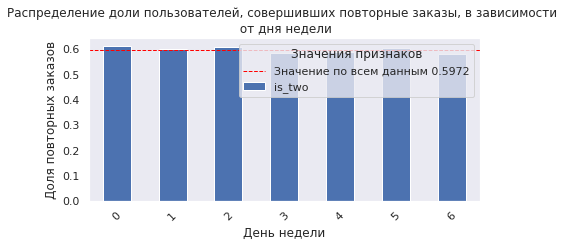

In [124]:
# Применим функцию и изучим распределение доли пользователей, совершивших повторные заказы, в зависимости от дня недели
title='Распределение доли пользователей, совершивших повторные заказы, в зависимости \n от дня недели'
xlabel='День недели'
ylabel='Доля повторных заказов'

plot_bar_plot(user_profile, 'day_week_order_dt_min', 'is_two', 'mean', title, ylabel, xlabel)

grouped_col = user_profile.groupby('day_week_order_dt_min')['is_two'].value_counts().unstack(fill_value=0)

<div style="background-color: #f0f0f0; padding: 10px; border-radius: 5px;">
    
**Вывод по задаче 4.3.1. Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей**

Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

- Нет четкой зависимости между днём недели и долей повторных закаров. Значения находятся около среднего. Однако можно отметить тенденцию, что в воскресенье и вторник повторных заказов больше среднего.

</div>

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


In [125]:
#Создали столбец tickets_group
def categorize2_5(value):
    if 2<=value<=4:
        return 'от 2 до 4 заказов'
    elif value>=5:
        return 'от 5 и более заказов'

user_profile['orders_group2_5']=user_profile['order_id_count'].apply(categorize2_5)

In [126]:
user_profile.head()

,user_id,order_dt_min,order_dt_max,device_type_canonical_first,region_name_first,service_name_first,event_type_main_first,order_id_count,revenue_rub_mean,tickets_count_mean,hours_order_ts_mean,days_since_prev_mean,is_two,is_five,tickets_group,day_week_order_dt_min,orders_group2_5
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,каменевский регион,край билетов,театр,1,1521.939941,4.000000,NaN,NaN,0,0,от 1 до 2 билетов,1,None
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,каменевский регион,мой билет,выставки,2,774.010010,3.000000,1795.327222,75.0,1,0,от 2 до 3 билетов,1,от 2 до 4 заказов
2,000898990054619,2024-07-13,2024-10-23,mobile,североярская область,лови билет!,другое,3,767.213318,2.666667,1221.760000,51.0,1,0,от 3 до 5 билетов,5,от 2 до 4 заказов
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,каменевский регион,край билетов,театр,1,917.830017,4.000000,NaN,NaN,0,0,от 1 до 2 билетов,3,None
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,поленовский край,лучшие билеты,театр,2,61.309998,1.500000,374.831111,16.0,1,0,от 2 до 3 билетов,6,от 2 до 4 заказов


Рассчитаем среднее время между заказами для двух групп пользователей:
совершившие 2–4 заказа;
совершившие 5 и более заказов.


In [127]:
group_hours_order_ts_mean=user_profile.groupby('orders_group2_5')['days_since_prev_mean'].mean()

In [128]:
group_hours_order_ts_mean

orders_group2_5
от 2 до 4 заказов       21.217505
от 5 и более заказов    11.081757
Name: days_since_prev_mean, dtype: float32

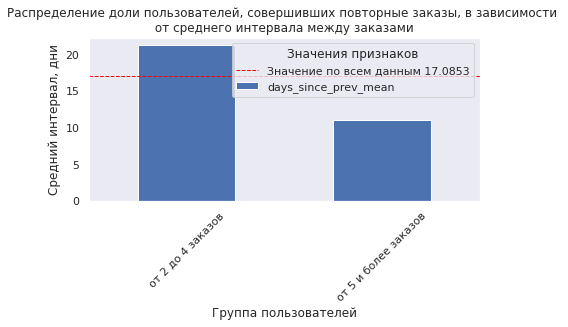

In [174]:
# Применим функцию и изучим распределение доли пользователей, совершивших повторные заказы, в зависимости от дня недели
title='Распределение доли пользователей, совершивших повторные заказы, в зависимости \n от среднего интервала между заказами '
xlabel='Группа пользователей'
ylabel='Средний интервал, дни'

plot_bar_plot(user_profile, 'orders_group2_5', 'days_since_prev_mean', 'mean', title, ylabel, xlabel)


Среди пользователей, заказывающих более 5 заказов, средний интервал меньше почти в 2 раза (11% против 21%), по сравнению с теми, кто заказывает 2-4 раза.

Оценим распределение доли пользователей, совершивших повторные заказы, в зависимости от жанра первого посещённого мероприятия  event_type_main_first:

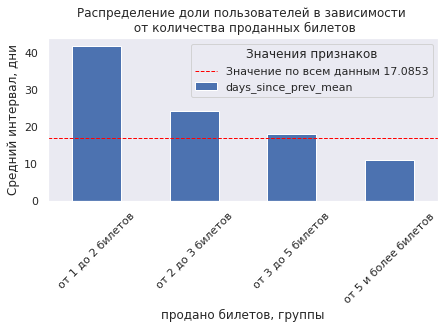

In [130]:
# Применим функцию и изучим распределение доли пользователей, совершивших повторные заказы, 

title='Распределение доли пользователей в зависимости \n от количества проданных билетов'
xlabel='продано билетов, группы'
ylabel='Средний интервал, дни'

plot_bar_plot(user_profile, 'tickets_group', 'days_since_prev_mean', 'mean', title, ylabel, xlabel)

Наблюдается обратная зависимость для покупки билетов по большему числу групп: от 2 билетов, 3 билетов и 5 и более. Значит зависимость есть и она обратная.

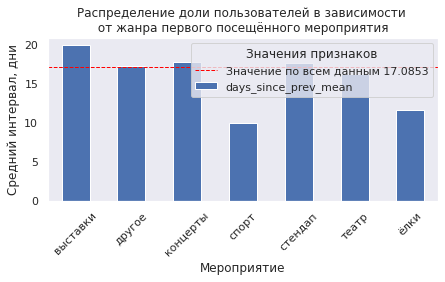

In [131]:
# Применим функцию и изучим распределение доли пользователей, совершивших повторные заказы, 
# в зависимости от жанра первого посещённого мероприятия event_type_main_first
title='Распределение доли пользователей в зависимости \n от жанра первого посещённого мероприятия '
xlabel='Мероприятие'
ylabel='Средний интервал, дни'

plot_bar_plot(user_profile, 'event_type_main_first', 'days_since_prev_mean', 'mean', title, ylabel, xlabel)

Чаще ходят на спортивные мероприятия, через 10 дней и ёлки, реже всего ходят на выставки (20 дней). Остальные значения близки к середине. Зависимость наблюдается от типа мероприятия event_type_main_first

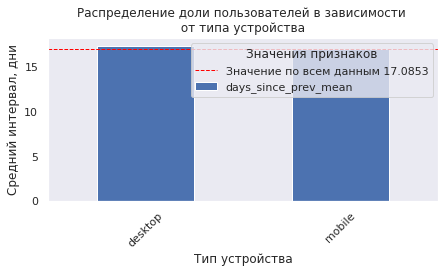

In [132]:
# Применим функцию и изучим распределение доли пользователей, совершивших повторные заказы, 

title='Распределение доли пользователей в зависимости \n от типа устройства '
xlabel='Тип устройства'
ylabel='Средний интервал, дни'

plot_bar_plot(user_profile, 'device_type_canonical_first', 'days_since_prev_mean', 'mean', title, ylabel, xlabel)

Тип устройства, с которого совершался первый заказ, не влияет на средний интервал между заказами

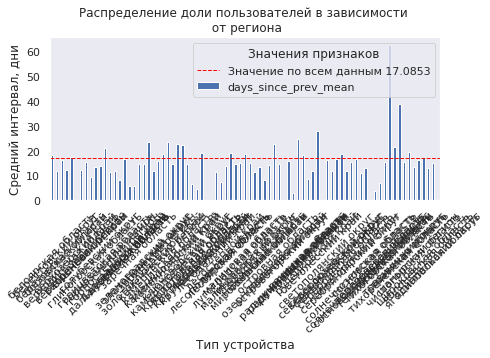

In [133]:
# Применим функцию и изучим распределение доли пользователей, совершивших повторные заказы, 

title='Распределение доли пользователей в зависимости \n от региона'
xlabel='Тип устройства'
ylabel='Средний интервал, дни'

plot_bar_plot(user_profile, 'region_name_first', 'days_since_prev_mean', 'mean', title, ylabel, xlabel)

In [134]:
group_days_since_prev_mean = user_profile.groupby('region_name_first')['days_since_prev_mean'].mean()
group_days_since_prev_mean1 = group_days_since_prev_mean[group_days_since_prev_mean < 16.98]
group_days_since_prev_mean2 = group_days_since_prev_mean[group_days_since_prev_mean > 16.98]

display(group_days_since_prev_mean1.sort_values(ascending=True))
display(group_days_since_prev_mean2.sort_values(ascending=True))

print(len(group_days_since_prev_mean1), len(group_days_since_prev_mean2))
 

region_name_first
верхозёрский край             0.000000
лесноярский край              0.000000
крутоводский регион           0.000000
радужногорская область        2.818182
сосновская область            3.813254
кристальная область           4.500000
залесский край                6.000000
дубравная область             6.000000
кристаловская область         6.575691
теплоозёрский округ           7.000000
лесополянская область         7.233333
нежинская область             8.074488
дальнеземская область         8.326885
речицкая область              8.541118
вишнёвский край               9.476515
солнечноземская область      11.165764
горноземский регион          11.352521
медовская область            11.502371
лесодальний край             11.637527
горностепной регион          11.683331
речицкий регион              11.887453
золотоключевской край        11.902172
серебринская область         11.944034
берестовский округ           12.015306
североключевской округ       12.036082
верхоре

region_name_first
широковская область       17.177023
верховинская область      17.500000
белоярская область        18.131542
речиновская область       18.398487
североярская область      18.543688
малиновая область         18.560272
каменевский регион        18.776983
лесоярская область        19.126532
крутоводская область      19.278646
травяная область          19.556843
горицветская область      20.913847
тихолесский край          21.504112
каменополянский округ     22.432575
каменноярский край        22.769922
озернопольская область    22.860394
каменичская область       23.453451
златопольский округ       23.615080
радужнопольский край      24.772600
ручейковский край         27.893847
тихореченская область     38.972252
тихогорская область       62.500000
Name: days_since_prev_mean, dtype: float32

56 21


Есть значения больше (21 регионов) и меньше (56 регион) среднего интервала заказа, значит возможно наличие зависимости.  

В лесноярском крае, верхозёрский крае и крутоводский регионе средний интервал между заказами - меньше дня.

21 регионов, выше среднего, то есть интервал между заказами большой, например, у тихореченской области(38 дней). А тихогорская область 62 дня, здесь рано делать вывод - мало данных по региону. А в регионах: дальнезорский край, нежинская область, горноземский регион - по 25 дней и т.д.  

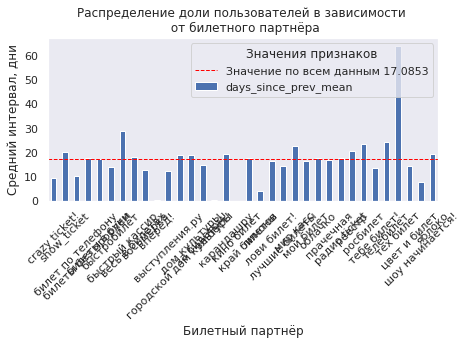

In [135]:
# Применим функцию и изучим распределение доли пользователей, совершивших повторные заказы, 

title='Распределение доли пользователей в зависимости \n от билетного партнёра'
xlabel='Билетный партнёр'
ylabel='Средний интервал, дни'

plot_bar_plot(user_profile, 'service_name_first', 'days_since_prev_mean', 'mean', title, ylabel, xlabel)

In [136]:
group_days_since_prev_mean = user_profile.groupby('service_name_first')['days_since_prev_mean'].mean()
group_days_since_prev_mean1 = group_days_since_prev_mean[group_days_since_prev_mean < 16.98]
group_days_since_prev_mean2 = group_days_since_prev_mean[group_days_since_prev_mean > 16.98]

display(group_days_since_prev_mean1.sort_values(ascending=True))
display(group_days_since_prev_mean2.sort_values(ascending=True))

print(len(group_days_since_prev_mean1), len(group_days_since_prev_mean2))

service_name_first
кино билет            0.000000
вперёд!               0.187500
зе бест!              0.500000
лимоны                4.066667
шоу начинается!       7.800000
crazy ticket!         9.470697
билет по телефону    10.303030
выступления.ру       12.434958
восьмёрка            12.848763
тебе билет!          13.578847
быстробилет          13.873435
лучшие билеты        14.228075
цвет и билет         14.409632
за билетом!          14.710655
мой билет            16.586428
лови билет!          16.596563
прачечная            16.770983
Name: days_since_prev_mean, dtype: float32

service_name_first
билеты в руки             17.150410
билеты без проблем        17.595234
облачко                   17.613218
радио ticket              17.643866
край билетов              17.695707
весь в билетах            17.893850
городской дом культуры    18.715519
дом культуры              18.861116
яблоко                    19.429895
карандашру                19.511110
show_ticket               20.155598
реестр                    20.440331
мир касс                  22.589684
росбилет                  23.473190
телебилет                 24.313789
быстрый кассир            28.726641
тех билет                 64.000000
Name: days_since_prev_mean, dtype: float32

17 17


От билетного партнёра зависимость наблюдается. кино билет, вперёд!, зе бест!- интервал заказа меньше дня. Тех билет - интервал 64 дня, по этому оператору мало данных.

Таким образом, в результате исследования, как средний интервал между заказами влияет на вероятность повторного заказа, был сделан вывод:

- среди пользователей, заказывающих более 5 заказов, средний интервал меньше почти в **2 раза** (11% против 21%), по сравнению с теми, кто заказывает 2-4 раза. (столбец `orders_group2_5`)
- наблюдается обратная **зависимость** для покупки билетов по большему числу групп: от 2 билетов, 3 билетов и 5 и более. Значит зависимость есть и она обратная: с увеличенеим **количества заказов**, сокращается **средний интервал** дней между заказами (столбец `tickets_count_mean`)
- **тип устройства** (столбец `device_type_canonical_first`), с которого совершался первый заказ, **не влияет** на средний интервал между заказами
- Есть зависимости между **регионом** (столбец `region_name_first`), **билетным оператором** (столбец `service_name_first`) и **средним интервалом** дней между заказами 


<div class="alert alert-info">  выбросы. Решила пересчитать, заменив среднее на медиану. В этом случае получатся более достоверные результаты:</div>

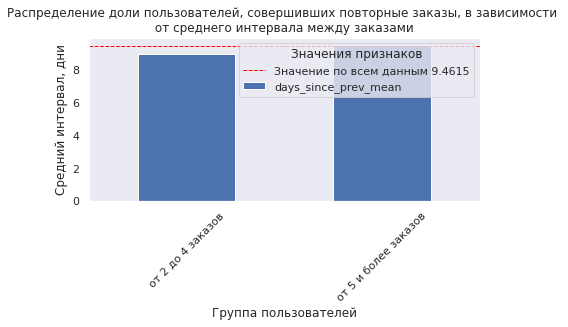

In [176]:
# Применим функцию и изучим распределение доли пользователей, совершивших повторные заказы, в зависимости от дня недели
title='Распределение доли пользователей, совершивших повторные заказы, в зависимости \n от среднего интервала между заказами '
xlabel='Группа пользователей'
ylabel='Средний интервал, дни'

plot_bar_plot(user_profile, 'orders_group2_5', 'days_since_prev_mean', 'median', title, ylabel, xlabel)


<div class="alert alert-info"> 
Среди пользователей, заказывающих от 2х до 4х заказов и более 5 заказов, средний интервал практически не отличается. Зависимости от среднего интеравла нет.

Оценим распределение доли пользователей, совершивших повторные заказы, в зависимости от жанра первого посещённого мероприятия event_type_main_first:
</div>

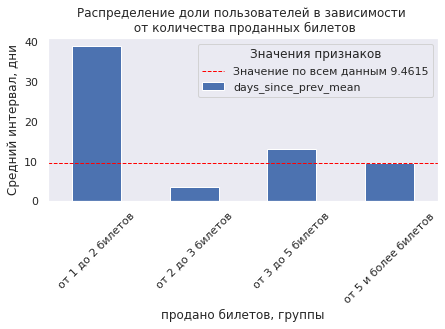

In [177]:
# Применим функцию и изучим распределение доли пользователей, совершивших повторные заказы, 

title='Распределение доли пользователей в зависимости \n от количества проданных билетов'
xlabel='продано билетов, группы'
ylabel='Средний интервал, дни'

plot_bar_plot(user_profile, 'tickets_group', 'days_since_prev_mean', 'median', title, ylabel, xlabel)

<div class="alert alert-info">
Наблюдается некоторая обратная зависимость для покупки билетов по большему числу групп: от 1 билета, 3 билетов и 5 и более. Самый большой интервал между покупками, около 38 дней, по продажам за - 1 билет. Значит зависимость  есть и она обратная.

Чаще всего покупают 2 билета (минимальный интервал), средний интервал - около 3х дней. 
 
</div>

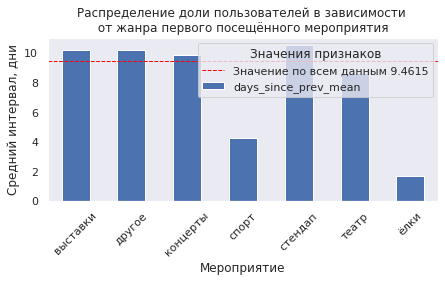

In [178]:
# Применим функцию и изучим распределение доли пользователей, совершивших повторные заказы, 
# в зависимости от жанра первого посещённого мероприятия event_type_main_first
title='Распределение доли пользователей в зависимости \n от жанра первого посещённого мероприятия '
xlabel='Мероприятие'
ylabel='Средний интервал, дни'

plot_bar_plot(user_profile, 'event_type_main_first', 'days_since_prev_mean', 'median', title, ylabel, xlabel)

<div class="alert alert-info"> 

Чаще ходят на спортивные мероприятия, примерно через 5 дней и ёлки, реже всего ходят на стендапы (14), выставки (12 дней) и другое (12 дней). Остальные значения близки к середине. Зависимость наблюдается от типа мероприятия event_type_main_first
    </div>

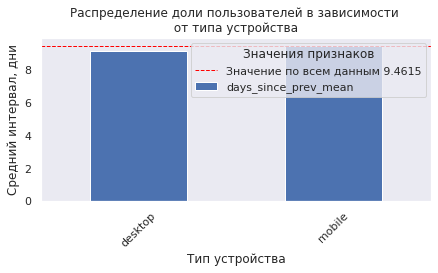

In [182]:
# Применим функцию и изучим распределение доли пользователей, совершивших повторные заказы, 

title='Распределение доли пользователей в зависимости \n от типа устройства '
xlabel='Тип устройства'
ylabel='Средний интервал, дни'

plot_bar_plot(user_profile, 'device_type_canonical_first', 'days_since_prev_mean', 'median', title, ylabel, xlabel)


<div class="alert alert-info"> 
Тип устройства, с которого совершался первый заказ, не влияет на средний интервал между заказами
    </div>

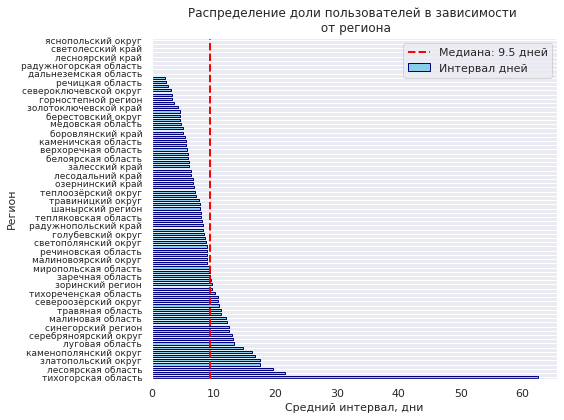

In [202]:
# Группируем данные и считаем медиану
grouped = user_profile.groupby('region_name_first')['days_since_prev_mean'].median().sort_values(ascending=False)
grouped.name ='Интервал дней'
# Создаём график
ax = grouped.plot(
    kind='barh',
    title='Распределение доли пользователей в зависимости \n от региона',
    figsize=(8, 6),
    color='skyblue',
    edgecolor='navy',
    linewidth=1
)

# Рассчитываем общую медиану по всем данным
overall_median = user_profile['days_since_prev_mean'].median()

# Добавляем линию общей медианы
ax.axvline(overall_median, color='red', linestyle='--', linewidth=2,
           label=f'Медиана: {overall_median:.1f} дней')

# Настраиваем внешний вид
ax.set_xlabel('Средний интервал, дни', fontsize=11)
ax.set_ylabel('Регион', fontsize=11)  
ax.grid(axis='x', alpha=0.3)  # Только сетка по оси X для лучшей читаемости

# Получаем текущие метки оси Y
current_labels = ax.get_yticklabels()

# Оставляем только каждую вторую метку
ax.set_yticklabels([label if i % 2 == 0 else '' for i, label in enumerate(current_labels)], fontsize=9)

# Дополнительно: уменьшаем размер шрифта оставшихся меток, чтобы они не загромождали график
plt.legend(loc='upper right')  # Добавляем легенду справа вверху
plt.tight_layout()  # Автоматическая подгонка элементов
plt.show()
 

In [203]:
group_days_since_prev_mean = user_profile.groupby('region_name_first')['days_since_prev_mean'].median()
group_days_since_prev_mean1 = group_days_since_prev_mean[group_days_since_prev_mean < 9.5]
group_days_since_prev_mean2 = group_days_since_prev_mean[group_days_since_prev_mean > 9.5]

display(group_days_since_prev_mean1.sort_values(ascending=True))
display(group_days_since_prev_mean2.sort_values(ascending=True))

print(len(group_days_since_prev_mean1), len(group_days_since_prev_mean2))
 

region_name_first
дальнеземская область        0.000000
радужногорская область       0.000000
крутоводский регион          0.000000
лесноярский край             0.000000
верхозёрский край            0.000000
кристаловская область        2.153846
речицкая область             2.250000
сосновская область           2.684211
североключевской округ       3.100000
вишнёвский край              3.300000
горностепной регион          3.333333
нежинская область            3.600000
золотоключевской край        4.250000
кристальная область          4.500000
берестовский округ           4.550000
солнечноземская область      4.583333
медовская область            4.666667
чистогорская область         5.043478
боровлянский край            5.125000
серебринская область         5.352273
каменичская область          5.507053
речицкий регион              5.550000
верхоречная область          5.666667
ягодиновская область         5.800000
белоярская область           5.863636
залесский край               6.0

region_name_first
островная область          9.666667
зоринский регион           9.691667
ветренский регион          9.800000
тихореченская область     10.166667
североярская область      10.750000
североозёрский округ      10.800000
каменевский регион        10.909091
травяная область          11.200000
зеленоградский округ      11.250000
малиновая область         12.000000
дальнезорский край        12.125000
синегорский регион        12.500000
тихолесский край          12.545455
серебряноярский округ     12.975000
берёзовская область       13.125000
луговая область           13.250000
каменноярский край        14.777779
каменополянский округ     16.250000
озернопольская область    16.666668
златопольский округ       17.472221
верховинская область      17.500000
лесоярская область        19.666666
ручейковский край         21.500000
тихогорская область       62.500000
Name: days_since_prev_mean, dtype: float32

53 24


<div class="alert alert-info"> 
Есть значения больше и меньше среднего интервала заказа, значит возможно наличие зависимости.

В яснопольском округе,светлолесском крае, лесноярском крае средний интервал между заказами - меньше дня.

Самый большой интервал между заказами, 62 дня, в тихогорской области 62 дня, здесь рано делать вывод - мало данных по региону. 
    </div>

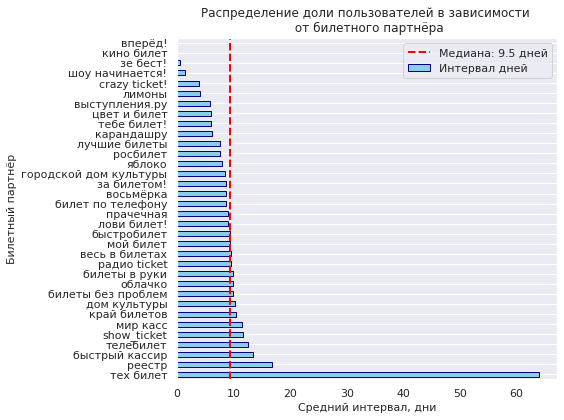

In [201]:
# Группируем данные и считаем медиану
grouped = user_profile.groupby('service_name_first')['days_since_prev_mean'].median().sort_values(ascending=False)
grouped.name ='Интервал дней'
# Создаём график
ax = grouped.plot(
    kind='barh',
    title='Распределение доли пользователей в зависимости \n от билетного партнёра',
    figsize=(8, 6),
    color='skyblue',
    edgecolor='navy',
    linewidth=1
)

# Рассчитываем общую медиану по всем данным
overall_median = user_profile['days_since_prev_mean'].median()

# Добавляем линию общей медианы
ax.axvline(overall_median, color='red', linestyle='--', linewidth=2,
           label=f'Медиана: {overall_median:.1f} дней')

# Настраиваем внешний вид
ax.set_xlabel('Средний интервал, дни', fontsize=11)
ax.set_ylabel('Билетный партнёр', fontsize=11)  
ax.grid(axis='x', alpha=0.3)  # Только сетка по оси X для лучшей читаемости


# Дополнительно: уменьшаем размер шрифта оставшихся меток, чтобы они не загромождали график
plt.legend(loc='upper right')  # Добавляем легенду справа вверху
plt.tight_layout()  # Автоматическая подгонка элементов
plt.show()

In [204]:
group_days_since_prev_mean = user_profile.groupby('service_name_first')['days_since_prev_mean'].median()
group_days_since_prev_mean1 = group_days_since_prev_mean[group_days_since_prev_mean < 9.5]
group_days_since_prev_mean2 = group_days_since_prev_mean[group_days_since_prev_mean > 9.5]

display(group_days_since_prev_mean1.sort_values(ascending=True))
display(group_days_since_prev_mean2.sort_values(ascending=True))

print(len(group_days_since_prev_mean1), len(group_days_since_prev_mean2))

service_name_first
кино билет                0.000000
вперёд!                   0.000000
зе бест!                  0.500000
шоу начинается!           1.500000
crazy ticket!             3.875000
лимоны                    4.066667
выступления.ру            5.833333
тебе билет!               6.000000
цвет и билет              6.000000
карандашру                6.222222
лучшие билеты             7.649123
росбилет                  7.650000
яблоко                    7.964286
городской дом культуры    8.500000
за билетом!               8.607143
восьмёрка                 8.651584
билет по телефону         8.666667
прачечная                 8.958334
лови билет!               9.000000
быстробилет               9.416666
мой билет                 9.428572
Name: days_since_prev_mean, dtype: float32

service_name_first
радио ticket           9.571428
билеты в руки          9.857142
билеты без проблем    10.000000
облачко               10.000000
дом культуры          10.354166
край билетов          10.428572
мир касс              11.500000
show_ticket           11.625000
телебилет             12.500000
быстрый кассир        13.444445
реестр                16.875000
тех билет             64.000000
Name: days_since_prev_mean, dtype: float32

21 12


<div class="alert alert-info"> 
От билетного партнёра зависимость наблюдается. кино билет, вперёд!, зе бест!- интервал заказа меньше дня. Тех билет - интервал 64 дня, по этому оператору мало данных.
    </div>

<div class="alert alert-info"> 
    
Таким образом, с учетом выбросов, несколько изменились выводы по столбцам: `orders_group2_5`, `tickets_group`, `event_type_main_first`, `region_name_first` . 
    
Без изменений остались: `device_type_canonical_first` и `service_name_first`
    </div>

<div class="alert alert-info"> Таким образом, в результате исследования, как средний интервал между заказами влияет на вероятность **повторного**  заказа, был сделан вывод:

- cреди пользователей, заказывающих от **2х** до **4х** заказов и более **5** заказов, средний интервал практически не отличается. **Зависимости** от среднего интеравла **нет** (столбец `orders_group2_5`); 
- наблюдается некоторая **обратная зависимость** для покупки билетов по большему числу групп: от 2 билетов, 3 билетов и 5 и более. Значит зависимость  есть и она обратная (столбец `tickets_count_mean`). Чаще всего покупают **2** билета, средний интервал - около **3х дней**. Самый большой интервал между покупками, около 38 дней, по продажам за - 1 билет;
- чаще ходят на спортивные мероприятия, примерно через 5 дней и ёлки (2 дня), реже всего ходят на стендапы (14), выставки (12 дней) и другое (12 дней). Остальные значения близки к середине. Зависимость наблюдается от типа мероприятия `event_type_main_first`;
- тип устройства, с которого совершался первый заказ, не влияет на средний интервал между заказами (столбец `device_type_canonical_first`);
- есть зависимости между **регионом** (столбец `region_name_first`), **билетным оператором** (столбец `service_name_first`).
    </div>

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

Рассчитайте коэффициент корреляции phi_k между признаками профиля пользователя и числом заказов (total_orders у меня это столбец order_id_count). При необходимости используйте параметр interval_cols для определения интервальных данных.

К каким столбцам применить пареметр interval_cols? Для day_week_order_dt_min и revenue_rub_mean. Для других числовых полей (1)tickets_count_mean, 2)order_id_count) уже много дополнительных столбцов (1) tickets_group 2) is_two, is_five, orders_group2_5), больше не надо.

**user_profile** Корреляционная матрица с коэффициентом phi_k для переменной `order_id_count`

In [137]:
# Вычисляем корреляционную матрицу с использованием phi_k
correlation_matrix1 = user_profile[['order_id_count', 'revenue_rub_mean', 'tickets_count_mean', 'days_since_prev_mean',
                                   'day_week_order_dt_min','device_type_canonical_first','service_name_first',
                                    'event_type_main_first']].phik_matrix()

# Выводим результат
print('Корреляционная матрица с коэффициентом phi_k для переменной order_id_count')
correlation_matrix1.loc[correlation_matrix1.index != 'order_id_count'][['order_id_count']].sort_values(by='order_id_count', ascending=False)

interval columns not set, guessing: ['order_id_count', 'revenue_rub_mean', 'tickets_count_mean', 'days_since_prev_mean', 'day_week_order_dt_min']
Корреляционная матрица с коэффициентом phi_k для переменной order_id_count


,order_id_count
days_since_prev_mean,0.465085
tickets_count_mean,0.276813
revenue_rub_mean,0.252036
service_name_first,0.050251
event_type_main_first,0.036981
device_type_canonical_first,0.031565
day_week_order_dt_min,0.018045


new_us - датафрейм, в котором исключены записи больше 0,95 процентиля поля revenue_rub_mean датафрейма user_profile. И сравню результаты с матрицей correlation_matrix

In [138]:
new_us=user_profile.copy()

In [139]:
q95=new_us['revenue_rub_mean'].quantile(0.95)
new_us=new_us[new_us['revenue_rub_mean']<q95]

**new_us** Корреляционная матрица с коэффициентом phi_k для переменной `order_id_count`

In [140]:
# Вычисляем корреляционную матрицу с использованием phi_k
correlation_matrix3 = new_us[['order_id_count', 'revenue_rub_mean', 'tickets_count_mean', 'days_since_prev_mean', 
                             'day_week_order_dt_min','device_type_canonical_first','service_name_first',
                                    'event_type_main_first','region_name_first']].phik_matrix()

# Выводим результат
print('Корреляционная матрица с коэффициентом phi_k для переменной order_id_count')
correlation_matrix3.loc[correlation_matrix3.index != 'order_id_count'][['order_id_count']].sort_values(by='order_id_count', ascending=False)

interval columns not set, guessing: ['order_id_count', 'revenue_rub_mean', 'tickets_count_mean', 'days_since_prev_mean', 'day_week_order_dt_min']
Корреляционная матрица с коэффициентом phi_k для переменной order_id_count


,order_id_count
days_since_prev_mean,0.471374
tickets_count_mean,0.264521
revenue_rub_mean,0.245208
service_name_first,0.056097
event_type_main_first,0.042011
device_type_canonical_first,0.036332
region_name_first,0.026563
day_week_order_dt_min,0.019166


**Создание списка интервальных переменных для параметра interval_cols**

interval_cols = [
    #'day_week_order_dt_min',  # дни недели
    'revenue_rub_mean'        # суммарный доход
]

phik_mat = phik_matrix(
    user_profile,
    interval_cols=interval_cols
)

Убивается ядро. Попробую для теста сократить число записей. Возьму датафраме **new_us** для 0,95 процентиля

In [141]:
new_us_4col=new_us[['revenue_rub_mean', 'day_week_order_dt_min','order_id_count']]

interval_cols = [
    'day_week_order_dt_min',  # дни недели
    'revenue_rub_mean'        # суммарный доход
]

phik_mat = phik_matrix(
    new_us_4col,
    interval_cols=interval_cols
)

print(phik_mat)

                       revenue_rub_mean  day_week_order_dt_min  order_id_count
revenue_rub_mean               1.000000               0.031927          0.2494
day_week_order_dt_min          0.031927               1.000000          0.0000
order_id_count                 0.249400               0.000000          1.0000


# Сегментация по orders_group2_5

 Изучаем сегмент **от 2 до 4 заказов**. Сохранили записи в датафрейм new_us_s2 6838 записей

In [142]:
new_us_s2=new_us[new_us['orders_group2_5']=='от 2 до 4 заказов']
new_us_s2=new_us_s2.copy()

In [143]:
# Вычисляем корреляционную матрицу с использованием phi_k
correlation_matrix = new_us_s2[['order_id_count', 'revenue_rub_mean', 'tickets_count_mean', 'days_since_prev_mean', 
                             'day_week_order_dt_min','device_type_canonical_first','service_name_first',
                                    'event_type_main_first','region_name_first']].phik_matrix()

# Выводим результат
print('Корреляционная матрица с коэффициентом phi_k для переменной order_id_count')
correlation_matrix.loc[correlation_matrix.index != 'order_id_count'][['order_id_count']].sort_values(by='order_id_count', ascending=False)

interval columns not set, guessing: ['order_id_count', 'revenue_rub_mean', 'tickets_count_mean', 'days_since_prev_mean', 'day_week_order_dt_min']
Корреляционная матрица с коэффициентом phi_k для переменной order_id_count


,order_id_count
days_since_prev_mean,0.384584
tickets_count_mean,0.369719
revenue_rub_mean,0.109045
service_name_first,0.068243
device_type_canonical_first,0.010292
day_week_order_dt_min,0.000000
event_type_main_first,0.000000
region_name_first,0.000000


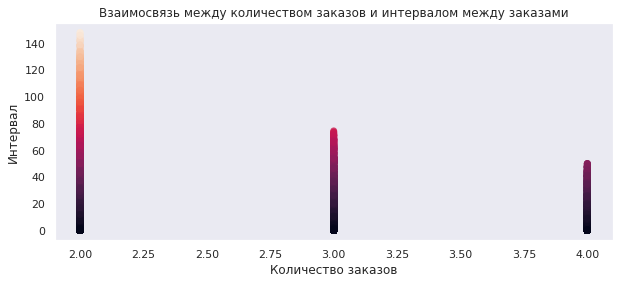

In [144]:
# Создаём контейнер графика
plt.figure(figsize=(10, 4))

# Строим диаграмму рассеяния с указанием цвета каждой точки
colors = new_us_s2['days_since_prev_mean']  # Здесь нужно указать столбец с категориальной переменной, которая будет определять цвет
plt.scatter(new_us_s2['order_id_count'],
            new_us_s2['days_since_prev_mean'],
            c=colors,  # Указываем массив цветов
            marker='o',  # Задаём стиль маркера
            alpha=0.7)

# Добавляем заголовок и метки осей
plt.title('Взаимосвязь между количеством заказов и интервалом между заказами')
plt.xlabel('Количество заказов')
plt.ylabel('Интервал')
plt.grid()


# Отображаем график
plt.show()

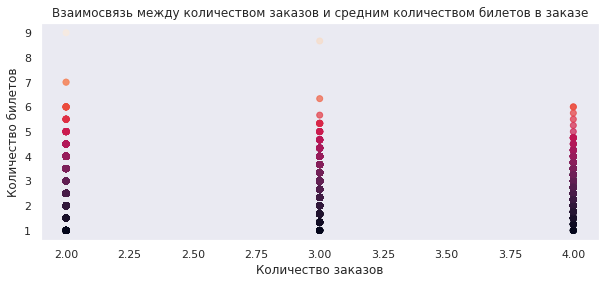

In [145]:
# Создаём контейнер графика
plt.figure(figsize=(10, 4))

# Строим диаграмму рассеяния с указанием цвета каждой точки
colors = new_us_s2['tickets_count_mean']  # Здесь нужно указать столбец с категориальной переменной, которая будет определять цвет
plt.scatter(new_us_s2['order_id_count'],
            new_us_s2['tickets_count_mean'],
            c=colors,  # Указываем массив цветов
            marker='o',  # Задаём стиль маркера
            alpha=0.7)

# Добавляем заголовок и метки осей
plt.title('Взаимосвязь между количеством заказов и средним количеством билетов в заказе')
plt.xlabel('Количество заказов')
plt.ylabel('Количество билетов')
plt.grid()

# Отображаем график
plt.show()

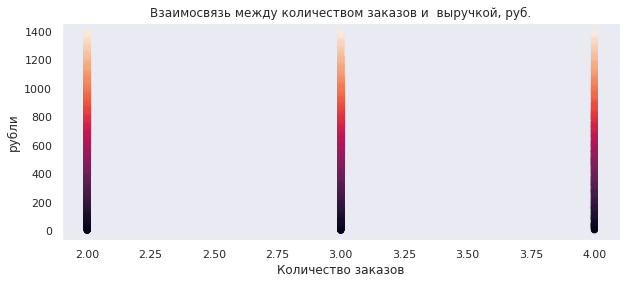

In [146]:
# Создаём контейнер графика
plt.figure(figsize=(10, 4))

# Строим диаграмму рассеяния с указанием цвета каждой точки
colors = new_us_s2['revenue_rub_mean']  # Здесь нужно указать столбец с категориальной переменной, которая будет определять цвет
plt.scatter(new_us_s2['order_id_count'],
            new_us_s2['revenue_rub_mean'],
            c=colors,  # Указываем массив цветов
            marker='o',  # Задаём стиль маркера
            alpha=0.7)

# Добавляем заголовок и метки осей
plt.title('Взаимосвязь между количеством заказов и  выручкой, руб.')
plt.xlabel('Количество заказов')
plt.ylabel('рубли')
plt.grid()

# Отображаем график
plt.show()

Изучаем сегмент **более 5 заказов**. Сохранили записи в датафрейм new_us_s3

In [147]:
new_us_s3=new_us[new_us['orders_group2_5']=='от 5 и более заказов']
new_us_s3=new_us_s3.copy()

In [148]:
# Вычисляем корреляционную матрицу с использованием phi_k
correlation_matrix = new_us_s3[['order_id_count', 'revenue_rub_mean', 'tickets_count_mean', 'days_since_prev_mean', 
                             'day_week_order_dt_min','device_type_canonical_first','service_name_first',
                                    'event_type_main_first','region_name_first']].phik_matrix()

# Выводим результат
print('Корреляционная матрица с коэффициентом phi_k для переменной order_id_count')
correlation_matrix.loc[correlation_matrix.index != 'order_id_count'][['order_id_count']].sort_values(by='order_id_count', ascending=False)

interval columns not set, guessing: ['order_id_count', 'revenue_rub_mean', 'tickets_count_mean', 'days_since_prev_mean', 'day_week_order_dt_min']
Корреляционная матрица с коэффициентом phi_k для переменной order_id_count


,order_id_count
days_since_prev_mean,0.704990
revenue_rub_mean,0.179868
tickets_count_mean,0.127368
region_name_first,0.079391
event_type_main_first,0.072757
day_week_order_dt_min,0.028334
device_type_canonical_first,0.014286
service_name_first,0.000000


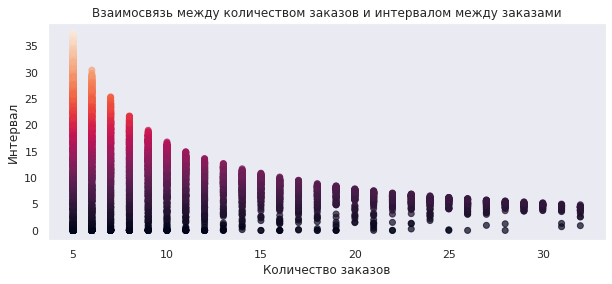

In [149]:
# Создаём контейнер графика
plt.figure(figsize=(10, 4))

# Строим диаграмму рассеяния с указанием цвета каждой точки
colors = new_us_s3['days_since_prev_mean']  # Здесь нужно указать столбец с категориальной переменной, которая будет определять цвет
plt.scatter(new_us_s3['order_id_count'],
            new_us_s3['days_since_prev_mean'],
            c=colors,  # Указываем массив цветов
            marker='o',  # Задаём стиль маркера
            alpha=0.7)

# Добавляем заголовок и метки осей
plt.title('Взаимосвязь между количеством заказов и интервалом между заказами')
plt.xlabel('Количество заказов')
plt.ylabel('Интервал')
plt.grid()


# Отображаем график
plt.show()

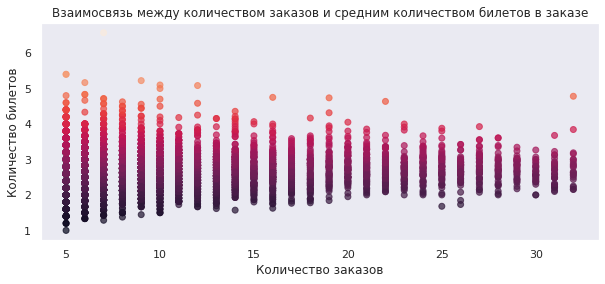

In [150]:
# Создаём контейнер графика
plt.figure(figsize=(10, 4))

# Строим диаграмму рассеяния с указанием цвета каждой точки
colors = new_us_s3['tickets_count_mean']  # Здесь нужно указать столбец с категориальной переменной, которая будет определять цвет
plt.scatter(new_us_s3['order_id_count'],
            new_us_s3['tickets_count_mean'],
            c=colors,  # Указываем массив цветов
            marker='o',  # Задаём стиль маркера
            alpha=0.7)

# Добавляем заголовок и метки осей
plt.title('Взаимосвязь между количеством заказов и средним количеством билетов в заказе')
plt.xlabel('Количество заказов')
plt.ylabel('Количество билетов')
plt.grid()

# Отображаем график
plt.show()

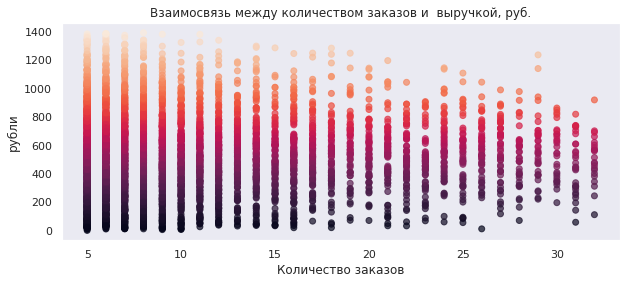

In [151]:
# Создаём контейнер графика
plt.figure(figsize=(10, 4))

# Строим диаграмму рассеяния с указанием цвета каждой точки
colors = new_us_s3['revenue_rub_mean']  # Здесь нужно указать столбец с категориальной переменной, которая будет определять цвет
plt.scatter(new_us_s3['order_id_count'],
            new_us_s3['revenue_rub_mean'],
            c=colors,  # Указываем массив цветов
            marker='o',  # Задаём стиль маркера
            alpha=0.7)

# Добавляем заголовок и метки осей
plt.title('Взаимосвязь между количеством заказов и  выручкой, руб.')
plt.xlabel('Количество заказов')
plt.ylabel('рубли')
plt.grid()

# Отображаем график
plt.show()

Изучаем сегмент **1 заказ**. Сохранили записи в датафрейм new_us_s1

In [152]:
new_us_s1=new_us[new_us['order_id_count']==1]
new_us_s1=new_us_s1.copy()
print(new_us_s1.shape[0])

7656


In [153]:
# Вычисляем корреляционную матрицу с использованием phi_k
correlation_matrix_s1 = new_us_s1[['revenue_rub_mean','day_week_order_dt_min','tickets_count_mean', 
                                   'device_type_canonical_first','service_name_first',
                                   'event_type_main_first','region_name_first']].phik_matrix()

# Выводим результат
print('Корреляционная матрица с коэффициентом phi_k для переменной order_id_count')
correlation_matrix_s1.loc[correlation_matrix_s1.index != 'revenue_rub_mean'][['revenue_rub_mean']].sort_values(by='revenue_rub_mean', ascending=False)

interval columns not set, guessing: ['revenue_rub_mean', 'day_week_order_dt_min', 'tickets_count_mean']
Корреляционная матрица с коэффициентом phi_k для переменной order_id_count


,revenue_rub_mean
service_name_first,0.444081
region_name_first,0.443928
event_type_main_first,0.393107
tickets_count_mean,0.391253
device_type_canonical_first,0.084900
day_week_order_dt_min,0.047909


In [154]:
new_us_s1=new_us[['revenue_rub_mean', 'days_since_prev_mean','order_id_count']]

interval_cols = [
    'days_since_prev_mean', 
    'revenue_rub_mean'        # суммарный доход
]

phik_mat = phik_matrix(
    new_us_s1,
    interval_cols=interval_cols
)

print(phik_mat)

                      revenue_rub_mean  days_since_prev_mean  order_id_count
revenue_rub_mean              1.000000              0.131862        0.249400
days_since_prev_mean          0.131862              1.000000        0.496484
order_id_count                0.249400              0.496484        1.000000


In [155]:
new_us_s11=new_us[['tickets_count_mean','order_id_count']]

interval_cols = [
    'tickets_count_mean'
    
]

phik_mat = phik_matrix(
    new_us_s11,
    interval_cols=interval_cols
)

print(phik_mat)

                    tickets_count_mean  order_id_count
tickets_count_mean            1.000000        0.280075
order_id_count                0.280075        1.000000


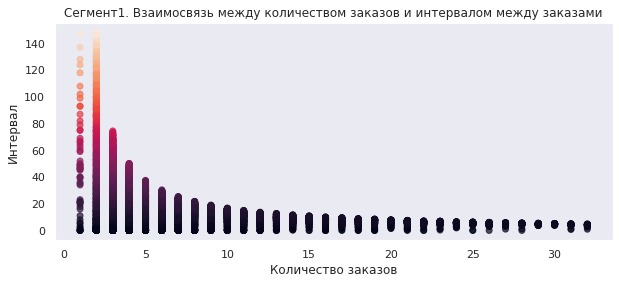

In [156]:
# Создаём контейнер графика
plt.figure(figsize=(10, 4))

# Строим диаграмму рассеяния с указанием цвета каждой точки
colors = new_us_s1['days_since_prev_mean']  # Здесь нужно указать столбец с категориальной переменной, которая будет определять цвет
plt.scatter(new_us_s1['order_id_count'],
            new_us_s1['days_since_prev_mean'],
            c=colors,  # Указываем массив цветов
            marker='o',  # Задаём стиль маркера
            alpha=0.7)

# Добавляем заголовок и метки осей
plt.title('Сегмент1. Взаимосвязь между количеством заказов и интервалом между заказами')
plt.xlabel('Количество заказов')
plt.ylabel('Интервал')
plt.grid()


# Отображаем график
plt.show()

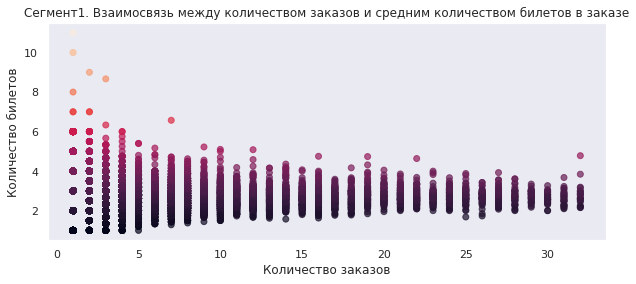

In [157]:
# Создаём контейнер графика
plt.figure(figsize=(10, 4))

# Строим диаграмму рассеяния с указанием цвета каждой точки
colors = new_us_s11['tickets_count_mean']  # Здесь нужно указать столбец с категориальной переменной, которая будет определять цвет
plt.scatter(new_us_s11['order_id_count'],
            new_us_s11['tickets_count_mean'],
            c=colors,  # Указываем массив цветов
            marker='o',  # Задаём стиль маркера
            alpha=0.7)

# Добавляем заголовок и метки осей
plt.title('Сегмент1. Взаимосвязь между количеством заказов и средним количеством билетов в заказе')
plt.xlabel('Количество заказов')
plt.ylabel('Количество билетов')
plt.grid()

# Отображаем график
plt.show()

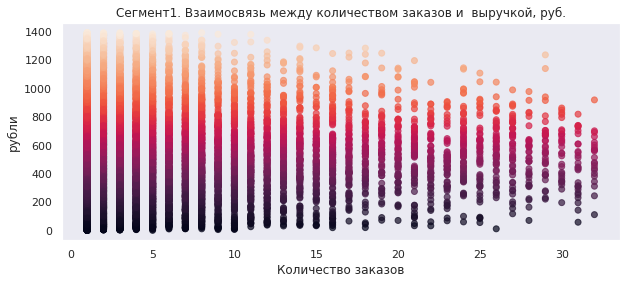

In [158]:
# Создаём контейнер графика
plt.figure(figsize=(10, 4))

# Строим диаграмму рассеяния с указанием цвета каждой точки
colors = new_us_s1['revenue_rub_mean']  # Здесь нужно указать столбец с категориальной переменной, которая будет определять цвет
plt.scatter(new_us_s1['order_id_count'],
            new_us_s1['revenue_rub_mean'],
            c=colors,  # Указываем массив цветов
            marker='o',  # Задаём стиль маркера
            alpha=0.7)

# Добавляем заголовок и метки осей
plt.title('Сегмент1. Взаимосвязь между количеством заказов и  выручкой, руб.')
plt.xlabel('Количество заказов')
plt.ylabel('рубли')
plt.grid()

# Отображаем график
plt.show()

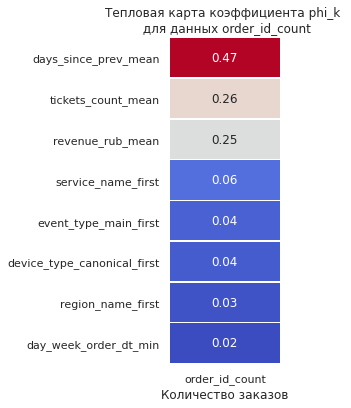

In [159]:
# Строим тепловую карту
plt.figure(figsize=(2, 6))

# Сохраняем матрицу корреляции 
data_heatmap = correlation_matrix3.loc[correlation_matrix3.index != 'order_id_count'][['order_id_count']].sort_values(by='order_id_count', ascending=False)
sns.heatmap(data_heatmap,
            annot=True, # Отображаем численные значения в ячейках карты
            fmt='.2f', # Форматируем значения корреляции: два знака после точки
            cmap='coolwarm', # Устанавливаем цветовую гамму от красного (макс. значение) к синему
            linewidths=0.5, # Форматируем линию между ячейками карты
            cbar=False # Отключаем цветовую шкалу
           )

# Добавляем заголовок и подпись по оси Х
plt.title('Тепловая карта коэффициента phi_k \n для данных order_id_count')
plt.xlabel('Количество заказов')

# Выводим график
plt.show()

При исследовании корреляции было установлено:
    Корреляции определялись  между `order_id_count` (общее количество заказов) и числовыми столбцами: `days_since_prev_mean` (	средний интервал между заказами), `revenue_rub_mean` (средняя выручка с одного заказа в рублях), `tickets_count_mean` (среднее количество билетов в заказе), `day_week_order_dt_min` (день недели первого заказа).
    
   1) определяли по всем записям (20865) профиля пользователя (датафрейм **user_profile**). В результате выявили средние связи `order_id_count` между средним интервалом между заказами (`days_since_prev_mean`) коэффициент **0,47** и средним количеством билетов в заказе (`tickets_count_mean`) коэфф. **0,3**.
    
   2) убрали аномально высокие значения, исключили записи больше 0,95 процентиля поля revenue_rub_mean датафрейма user_profile. Создали датафрейм - **new_us** (18819 записей). В результате, обнаружена умеренная прямая связь между `order_id_count` и средним временем между заказами (`days_since_prev_mean`) с коэффициентом **0,47**. А также две слабые связи со столбцами: среднее количество билетов в заказе (`tickets_count_mean`) с коэф. **0,26** и средняя выручка с одного заказа в рублях (`revenue_rub_mean`) с коэф. **0,23**

Провели сегментирование по полю `order_id_count`. Разбили его на 3 группы (1 заказ, от 2 до 4 заказов, от 5 и выше), сформировали три датафрейма (new_us_s1, new_us_s2, new_us_s3), в рамках которых были выявлены корреляции:

- **сегмент: 1 заказ (new_us_s1)**. Средняя связь `order_id_count` и `days_since_prev_mean` - коэфф. 0,5 (усиление связи), слабые связи с `revenue_rub_mean` (коэф. 0,24) и `tickets_count_mean` (коэф. 0,28).

Дополнительное исследование пользователей, совершивших первый заказ, выявило средние связи `revenue_rub_mean` c полями: `service_name_first`	(коэф. 0.45), `region_name_first`	(коэф. 0.44), `event_type_main_first`	(коэф. 0.4), `tickets_count_mean`	(коэф. 0.37)

- **сегмент: 2 заказ (new_us_s2)**. Две слабых связи для `order_id_count` с `days_since_prev_mean` - коэфф. 0,39 (ослабление связи), с `tickets_count_mean` - коэфф. 0,37 (усиление связи)
- **сегмент: 3 заказ (new_us_s3)**. Сильная связь `order_id_count` и `days_since_prev_mean` - коэфф. 0,7 (усиление связи)

Таким образом, на увеличение количества заказов влияет: средний интервал между заказами влияет на вероятность повторного заказа , а также в меньшей степени : среднее количество билетов в заказе, и средняя цена (выручка с одного заказа в рублях). 

Пользователи, совершаюшие разное количество заказов характеризуются по разному:
- кто совершает 1 заказ важно: в первую очередь, увеличение среднего интервала между заказами, влияет на вероятность повторного заказа, а так же количество билетов и цена заказа. Это группа новички

Для новичков, на выбор первого заказа влияют: регион в которм первый заказ осуществлён, билетный партнёр. А также, немного меньше, оказывают влияние: тип мероприятия и колиество билетов в заказе.

- кто заказывает от 2 до 4 заказов: сзависимость от среднего интервала между заказами падает. Для этой группы полбзователей это самый низкий коэфф 0,39. Но увеличивается значимость от количества билетов в заказе. 
- кто совершает от 5 и больше заказов: сильное влияние оказвает увеличение среднего интервала между заказами. Постоянные клиенты
Это может быть полезно для дальнейшего анализа и построения моделей. 



### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.

<div style="background-color: #f0f0f0; padding: 10px; border-radius: 5px;">
    
•	считали файл final_tickets_tenge_df.csv, сохранили в датафрейм exchange_rate
•	изучили exchange_rate
•	переименовали столбцы data в order_dt(чтобы связать по этому полю с df),cursвcurs_to_100kzt (для удобства, указали единицы измерения)
•	поле exchange_rate['order_dt'] преобразовали к типу datetime
•	с помощью merge объединили два датафрейма df и exchange_rate в result
•	рассчитали поле revenue_rub с помощью apply() лямбда-функции


- Понизили тип **int64** для полей `order_id`, `event_id`, `tickets_count`, а также  тип **float64** для поля `days_since_prev`.
- Пропуски поля days_since_prev не случайные пропуски.Они объясняются тем, что пользователь совершал только одну покупку, следовательно отнесём пропуски к виду MNAR.
- Категориальные данные представлены коректно, категории, которые обозначают пропуски в данных или отсутствие информации отсутствуют.
- В датафрейме **нет** явных **дубликатов**
- Удалено **112 неявных дубликата**, обнаруженных в записях по столбцам `user_id`,`device_type_canonical`,`order_ts`,`event_id`
- Поскольку очень разнородные данные, то применён к столбцу `revenue_rub` фильтр, отсавили значения меньше перцентиля **99** и значения выручки **>0**. Удалено из датафрейма **df 8909** (**0.03**) записей.
    
Всего строк в датафрейме **281590**


1. **Выручка в рублях** (`revenue_rub `) очень разнородные данные. Обнаружены выбросы. Поэтому применили к столбцу revenue_rub фильтр, оставили значения меньше перцентиля 99. Результаты стали более однородные, тенденция распределения сохранена. Также есть выбросы. Но графики стали более читабельны: 
Средняя (медианная) выручка в районе 356 рублей. 75% значений в пределах от -90 до 810р. Есть выбросы, правостороннее распределение. Отрицательная выручка означает наличие убыточных сервисов на данный момент, их доля 0.001317.
2. Количество купленных билетов`tickets_count`. В среднем покупают по 3 билета (медиана 3). Стандартное отклонение 1,17, значит скученность данных в центре. Размах =56, выбросы есть. Правосторонне распределение.
Гистограмма и ящик с усами подтверждают сделанные выводы. Выбросы не являются ошибкой.
3. Количество дней между этой покупкой и предыдущей `days_since_prev`. Сервисы популярны. Большая часть пользователей 75% сервисов использует их ежедневно. Но есть клиенты, использующие сервисы с интервалом от 1 до 148 дней, на их долю приходиться около 19%. Есть с чем работать.
4. `revenue` похоже на `revenue_rub`. `event_id` левостороннее распределение с выбросами слева, т.е. есть более популярные сервисы.
order_id нормальное распределение.
</div>

- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?

<div style="background-color: #f0f0f0; padding: 10px; border-radius: 5px;">
    
Создан профиль пользователя в датафрейме **user_profile**
    
- общее число пользователей: 21933 
- средняя выручка с одного заказа: 574.02001953125
- доля пользователей, совершивших 2 и более заказа: 0.62
- доля пользователей, совершивших 5 и более заказа: 0.29

Данные в полях `order_id_count`,`tickets_count_mean`,`days_since_prev_mean` разнородны и содержат выбросы.
Поэтому было решено отфильтровать датафрейм **user_profile** на уровне 0.95 процентиля по полю `order_id_count`. Из выборки исключили **1068** запией (5% от датафрейма user_profile).

Пересчет описательных статистик позволил получить более однородные данные. Выбросы присутствуют, поэтому смотрим на медианные значения.


Итак, средний пользователь сервисов:  совершает два заказа с интервалом в 9 дней. Обычно покупает от2х до 3х билетов.

    
Пользователи по сегментам распределены неравномерно:
- по типу первого мероприятия, пользователи больше посещают: концетры (44.4%), другое (24.8%) и театры (19,6%)
- большая часть заказов впервые осуществляется с мобильного устройстава(mobile 82.9%), стационарные (desktop 17%), что практически в 5 раз меньше mobile
- регионами-лидерами по использованию сервиов являются: каменевский регион (32,8%), североярская область (17,2%)
- самыми популярными билетными операторами, продавшими билеты на первый заказ, являются: билеты без проблем (23,9%), мой билет (13,8%), лови билет! (13%), билеты в руки (11,6%) и облачко (10%).
</div>

    - Какие признаки первого заказа связаны с возвратом пользователей?
    
<div style="background-color: #f0f0f0; padding: 10px; border-radius: 5px;">
  
 Чаще возвращаются на Яндекс Афишу следующие сегменты пользователей:   
    
- для сегмента **"по типу первого мероприятия"**, поле `event_type_main_first`, чаще возвращаются на мероприятия: выставки, театр, концерты стендап и другое. Успешными "точками входа" являются выставки (0,626) и театры (0,620);
    
- для сегмента **по типу устройства**, поле `device_type_canonical_first`, чаще возвращаются те, кто заказывал со **стационарного** устройства (доля 0,62). Это и есть "точка входа";
    
- для сегмента **регион-лидер**, поле `region_name_first`, "точками входа", самыми успешными TOP-10 по привлечению регионами стали: шанырский регион (0,66), светополянский округ (0,64), широковская область (0,636), горицветская область (0,63), речицкий регион (0,63), берёзовская область (0,62), ветренский регион (0,62), североярская область (0,62), речиновская область (0,62) и заречная область (0,61);
    
- для сегмента **билетный оператор**, поле `service_name_first`, "точками входа", самыми быстрорастущими опрераторами стали: край билетов (0,64), show_ticket (0,64), дом культуры (0,63), мир касс (0,62), весь в билетах (0,61), билеты в руки (0,61), прачечная (0,60) и облачко (0,60).
</div>

<div style="background-color: #f0f0f0; padding: 10px; border-radius: 5px;">    
    
**Проверка гипотезы 2.**

**Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.

Гипотеза 1 подтверждается. Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: каждый второй возвращается на мероприятие (доля возврата от 0,54 до 0,63). 

Например, пользователи, которые совершили первый заказ на спортивные мероприятия (доля впервые привлеченных 3,7% (см. результаты задачи 4.1.1) ), совершают повторный заказ чаще (доля возврата 0,54 (см. задачу 4.1.2)), чем пользователи, оформившие свой первый заказ на концерты (0,44 см. результаты задачи 4.1.1).

**Проверка гипотезы 2.**

**Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

Гопитеза 2 **не подтверждается**. В регионах, где больше всего пользователей не самая высокая доля повторных заказов. Самая высокая доля повторных заказов (зад. 4.1.2), в регионах, где доля пользователей ниже 5%  (зад. 4.1.1).
    

Например, лидерами по повторным заказам (доли 0,66 и 0,64 соответственно) являются: шанырский регион и светополянский округ. Но пользователей в них зарегистрировано 470 и 441. В то время, как каменевский регион,  с числом пользователей 6841, находится на 11 месте (с доля 0,61).
        
</div>

<div class="alert alert-info"> Эти регионы очень чувствтиельны к изменениям. В них мало значений, поэтому добавление хотя-бы одной записи может сильно изменить долю повторного заказа </div>
    
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    
<div style="background-color: #f0f0f0; padding: 10px; border-radius: 5px;">
    
- Пользователи, совершающие один заказ (группа 0), в среднем готовы тратить на сервисы около 370 руб (диапазон от 0 до 370). 
- Пользователи, совершившие от 2-х заказов (группа 1) тратят в диапазоне от 300 до 700 руб, средний чек - 500руб. 
- Пользователи, совершившие от 5 заказов, тратят в среднем больше, чем лояльные клиенты группы 2+, в диапазоне от 300 до 800, а средний чек =524 руб.

Различия в группах, покупающих 1 заказ и 2+ более (группы 0 и 1): 
- группа 0, один заказ, характеризуется: выбросами, низким средним чеком, кратковременностью эффекта покупки;
- группа 1, 2 и более заказов, характеризуется: более высоким средним чеком, эффект покупки более длительный по времени, большей численностью пользователей
- группа 2, от 5 заказов, характеризуется более высоким диапазоном среднего чека, выше по сравнению с группой 1 (от 2-х и более заказов) и изменяется от  от 300 до 800. Клиенты группы 2 более сегментированы, меньше выбросов.
</div>

    
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
 
<div style="background-color: #f0f0f0; padding: 10px; border-radius: 5px;">
    
    Нет четкой зависимости между днём недели и долей повторных заказов. Однако можно отметить тенденцию, что в воскресенье и вторник повторных заказов больше среднего.
</div>

<div class="alert alert-info"> 
   Средний интервал между заказами влияет на вероятность повторного заказа, следующим образом:
    
- среди пользователей, заказывающих от **2х** до **4х** заказов и более **5** заказов, средний интервал практически не отличается (8.4% и 9.4%). **Зависимости** от среднего интеравла в 9.4 дня **нет**  ;
- наблюдается некоторая **обратная зависимость** для покупки билетов по большему числу групп: от 2 билетов, 3 билетов и 5 и более. Значит зависимость  есть и она обратная (столбец `tickets_count_mean`). Чаще всего покупают **2** билета, средний интервал - около **3х дней**. Самый большой интервал между покупками, около 38 дней, по продажам за - 1 билет;
- **тип устройства** (столбец `device_type_canonical_first`), с которого совершался первый заказ, **не влияет** на средний интервал между заказами;
- чаще ходят на спортивные мероприятия, примерно через 5 дней и ёлки (2 дня), реже всего ходят на стендапы (14), выставки (12 дней) и другое (12 дней); 
- есть зависимости между **регионом** , **билетным оператором**.
</div>
    
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
   
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

<div style="background-color: #f0f0f0; padding: 10px; border-radius: 5px;">

Таким образом, на увеличение количества заказов влияет: средний интервал между заказами влияет на вероятность повторного заказа , а также в меньшей степени : среднее количество билетов в заказе, и средняя цена (выручка с одного заказа в рублях). 
    
Пользователи, совершаюшие разное количество заказов характеризуются по разному:
- кто совершает 1 заказ важно: в первую очередь, увеличение среднего интервала между заказами, влияет на вероятность повторного заказа, а так же количество билетов и цена заказа. Это группа новички

Для новичков, на выбор первого заказа влияют: регион в которм первый заказ осуществлён, билетный партнёр. А также, немного меньше, оказывают влияние: тип мероприятия и количество билетов в заказе.

- кто заказывает от 2 до 4 заказов: зависимость от среднего интервала между заказами падает. Для этой группы пользователей это самый низкий коэфф 0,39. Но увеличивается значимость от количества билетов в заказе. 
- кто совершает от 5 и больше заказов: сильное влияние оказвает увеличение среднего интервала между заказами. Постоянные клиенты.
    
Таким образом, **поведение клиентов во времени** и **количество билетов** важнее для объяснения повторных покупок, чем их демография или первый выбор сервиса.**
</div>

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

<div style="background-color: #f0f0f0; padding: 10px; border-radius: 5px;">
    
**Рекомендации**
    
- **Привлечение новых клиентов**: привлечение не высокой ценой, около 370р. Имеет значение: тип первого мероприятия (концетры (44.4%), другое (24.8%) и театры (19,6%)), регион, билетный оператор. Привлечение начать с мобильного устройства, затем предложить пользователю заказывать со стационарного для его удержания. Наиболее активное население в   каменевский регион (32,8%)и североярская область (17,2%). Самыми популярными билетными операторами, продавшими билеты на первый заказ, являются: билеты без проблем (23,9%), мой билет (13,8%), лови билет! (13%), билеты в руки (11,6%) и облачко (10%)  
    
- **Возвращение клиентов** (сделать 2-й заказ): Предлагать новые мероприятия, например: спортивные мероприятия и ёлки - успешные "точки входа". Самая высокая доля повторных заказов (зад. 4.1.2), в регионах, где доля пользователей ниже 5%. Самыми успешными TOP-10 по привлечению регионами стали: шанырский регион (0,66), светополянский округ (0,64), широковская область (0,636), горицветская область (0,63), речицкий регион (0,63), берёзовская область (0,62), ветренский регион (0,62), североярская область (0,62), речиновская область (0,62) и заречная область (0,61). Самыми быстрорастущими опрераторами стали: край билетов (0,64), show_ticket (0,64), дом культуры (0,63), мир касс (0,62), весь в билетах (0,61), билеты в руки (0,61), прачечная (0,60) и облачко (0,60). Предлагать акции, на увеличение количества покупки билетов, например: два по цене одного.
    
- **Удержание клиентов**   Постоянным пользователям предлагать лимитированные, специальные предложения. Они готовы тратить больше (средний чек 524 руб., до 800 руб.), но их надо заинтересовать.
    
**Поведение клиентов во времени** и **количество билетов** важнее для объяснения повторных покупок, чем их демография или первый выбор сервиса.**    
</div>

### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**https://github.com/Konopatskaya/Afisha/tree/main**